<a href="https://www.kaggle.com/code/rodrigoramooos/modelacao-previsao-de-cancelamentos-em-voos?scriptVersionId=313975673" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Modelação do Projeto: Previsão de Atraso e Cancelamento de Voos

## Sumário
Este notebook atende à **Milestones 3**, mantendo a leitura dos dados **diretamente do Kaggle**.  
O objetivo desta versão é realizar a **fase de modelação** do projeto.

## 1. Importação de Bibliotecas e Configuração do Ambiente

In [1]:
# Bibliotecas para Modelação
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix

In [2]:
# Carregar dataset
df = pd.read_csv('/kaggle/input/datasets/rodrigoramooos/flight-data-processed/flight_data_processed.csv')

print('Tamanho:', df.shape)
df.head()

Tamanho: (1041151, 339)


,month,day_of_month,day_of_week,distance,is_long_flight,cancelled,origin_ABI,origin_ABQ,origin_ABR,origin_ABY,...,origin_USA,origin_VCT,origin_VEL,origin_VLD,origin_VPS,origin_WRG,origin_XNA,origin_XWA,origin_YAK,origin_YUM
0,1,1,1,-0.550093,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,-0.359439,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,-0.922965,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,-0.922965,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,-1.009013,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Definir variáveis
X = df.drop(columns=['cancelled'])
y = df['cancelled']

print('X:', X.shape)
print('y:', y.shape)

X: (1041151, 338)
y: (1041151,)


In [4]:
# Ver distribuição da variável alvo
y.value_counts(normalize=True) * 100

cancelled
0    98.472364
1     1.527636
Name: proportion, dtype: float64

In [5]:
# Divisão treino/teste (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (832920, 338)
Teste: (208231, 338)


In [6]:
# Confirmar distribuição
print('Treino (%):')
print(y_train.value_counts(normalize=True) * 100)

print('\nTeste (%):')
print(y_test.value_counts(normalize=True) * 100)

Treino (%):
cancelled
0    98.472362
1     1.527638
Name: proportion, dtype: float64

Teste (%):
cancelled
0    98.47237
1     1.52763
Name: proportion, dtype: float64


## 1.2. Definição de Métricas de Desempenho

O problema em estudo é uma classificação supervisionada com forte desequilíbrio de classes (~2.2% de cancelamentos), o que torna a escolha das métricas de avaliação crítica: métricas inadequadas podem mascarar um modelo que simplesmente prevê sempre a classe maioritária.

As métricas selecionadas foram:
* **F1-Score (Métrica Principal):** Média harmónica entre Precisão e Recall. Penaliza modelos que sacrificam uma das componentes, sendo a métrica mais adequada para datasets desequilibrados.
* **Recall / Sensibilidade:** Prioridade operacional — mede a proporção de cancelamentos reais detetados. Minimizar Falsos Negativos é essencial, pois prever incorretamente que um voo opera quando é cancelado acarreta custos logísticos elevados.
* **AUC-ROC:** Avalia a capacidade discriminativa do modelo ao longo de todos os limiares de decisão possíveis, independentemente do threshold escolhido.

In [7]:
# Importação das métricas de desempenho selecionadas para Classificação
from sklearn.metrics import (
    f1_score, 
    recall_score, 
    precision_score, 
    roc_auc_score, 
)

print("As métricas importadas com sucesso foram: F1-score, Recall, Precision e AUC-ROC.")

As métricas importadas com sucesso foram: F1-score, Recall, Precision e AUC-ROC.


## 2.1. Implementação do Modelo Baseline

Para estabelecer um referencial inicial de desempenho, foi implementado um modelo de baixa complexidade: a **Regressão Logística**. O objetivo nesta fase não é obter o melhor modelo possível, mas sim definir uma "linha de base" (baseline) de métricas. Assim, qualquer modelo mais complexo testado posteriormente deverá superar este desempenho inicial.

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
    )

print("A iniciar o treino do Modelo Baseline (Regressão Logística)...")

# Conversão temporária para float32 para reduzir custo computacional
X_train_fast = np.asarray(X_train, dtype=np.float32)
X_test_fast = np.asarray(X_test, dtype=np.float32)
y_train_fast = np.asarray(y_train)
y_test_fast = np.asarray(y_test)

# 1) Separar treino interno e validação para escolher o threshold sem usar o teste
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train_fast,
    y_train_fast,
    test_size=0.2,
    random_state=42,
    stratify=y_train_fast
)

# 2) Treinar modelo auxiliar no treino interno
baseline_model_val = LogisticRegression(
    max_iter=300,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)
baseline_model_val.fit(X_train_base, y_train_base)

# 3) Escolher threshold pela melhor métrica F1 na validação
y_val_proba = baseline_model_val.predict_proba(X_val_base)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)
f1_scores = []

for t in thresholds:
    y_val_pred_t = (y_val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val_base, y_val_pred_t, zero_division=0))

best_idx = int(np.argmax(f1_scores))
threshold = float(thresholds[best_idx])
best_f1_val = float(f1_scores[best_idx])

print(f"Threshold escolhido na validação: {threshold:.2f}")
print(f"Melhor F1 na validação: {best_f1_val:.4f}")

# 4) Treinar modelo final em todo o conjunto de treino
baseline_model = LogisticRegression(
    max_iter=300,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)
baseline_model.fit(X_train_fast, y_train_fast)

# 5) Previsões no teste
y_pred = baseline_model.predict(X_test_fast)
y_pred_proba = baseline_model.predict_proba(X_test_fast)[:, 1]
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# 6) Avaliação com threshold padrão
print("\n--- MATRIZ DE CONFUSÃO (Threshold = 0.50) ---")
print(confusion_matrix(y_test_fast, y_pred))

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.50) ---")
print(classification_report(y_test_fast, y_pred, zero_division=0))

# 7) AUC-ROC
auc_roc = roc_auc_score(y_test_fast, y_pred_proba)
print(f"\nAUC-ROC Score: {auc_roc:.4f}")

# 8) Avaliação com threshold escolhido na validação
print(f"\n--- MATRIZ DE CONFUSÃO (Threshold = {threshold:.2f}) ---")
print(confusion_matrix(y_test_fast, y_pred_adjusted))

print(f"\n--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = {threshold:.2f}) ---")
print(classification_report(y_test_fast, y_pred_adjusted, zero_division=0))

A iniciar o treino do Modelo Baseline (Regressão Logística)...
Threshold escolhido na validação: 0.70
Melhor F1 na validação: 0.0834

--- MATRIZ DE CONFUSÃO (Threshold = 0.50) ---
[[125115  79935]
 [   652   2529]]

--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.50) ---
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    205050
           1       0.03      0.80      0.06      3181

    accuracy                           0.61    208231
   macro avg       0.51      0.70      0.41    208231
weighted avg       0.98      0.61      0.75    208231


AUC-ROC Score: 0.7596

--- MATRIZ DE CONFUSÃO (Threshold = 0.70) ---
[[184108  20942]
 [  2163   1018]]

--- RELATÓRIO DE CLASSIFICAÇÃO (Threshold = 0.70) ---
              precision    recall  f1-score   support

           0       0.99      0.90      0.94    205050
           1       0.05      0.32      0.08      3181

    accuracy                           0.89    208231
   macro avg       0.52  

## 2.2. Treino e Avaliação Comparativa de Modelos Candidatos

Depois de definido o modelo baseline, avançamos agora para o teste de modelos de maior capacidade preditiva e comparar o respetivo desempenho de forma estruturada.

Nesta fase, o foco deixa de estar apenas na criação de uma linha de base e passa para a **experimentação**, mas sim procurar perceber se modelos mais robustos conseguem melhorar a capacidade de identificar voos cancelados.


Para esta comparação, foram selecionados modelos com características distintas:

- **Árvore de Decisão** — modelo interpretável que serve de referência base (*baseline*) para comparação;
- **Random Forest** — ensemble de árvores que reduz a variância por agregação, mais robusto ao ruído;
- **Extra Trees** — variante com aleatoriedade acrescida nos cortes, favorecendo a generalização;
- **HistGradient Boosting** — boosting por gradiente otimizado para dados tabulares, com suporte nativo a valores omissos;
- **XGBoost** — boosting de alto desempenho com regularização integrada e suporte a `scale_pos_weight` para classes desequilibradas;
- **Logistic Regression Calibrated** — modelo linear com probabilidades calibradas, útil como *baseline* probabilístico.

A comparação é feita com base nas métricas previamente definidas, com ênfase no **F1-Score**, no **Recall** e no **ROC-AUC**, dado o forte desequilíbrio entre classes (~65:1).


In [9]:
# Importacao dos modelos candidatos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

print("Modelos candidatos importados com sucesso.")

Modelos candidatos importados com sucesso.


In [10]:
# Definicao dos modelos candidatos
# Nota: os hiperparametros abaixo sao ajustes iniciais e nao substituem a otimizacao formal.

# scale_pos_weight = n_negativos / n_positivos — compensa o racio 65:1 no XGBoost
_scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

modelos_candidatos = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=60,
        max_depth=12,
        min_samples_split=40,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=60,
        max_depth=12,
        min_samples_split=40,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=42
    ),

    'HistGradient Boosting': HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=10,
        max_iter=200,
        min_samples_leaf=30,
        random_state=42
    ),

    'Logistic Regression Calibrated': CalibratedClassifierCV(
        estimator=LogisticRegression(
            max_iter=400,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        ),
        method='sigmoid',
        cv=3
    ),

    'XGBoost': XGBClassifier(
        scale_pos_weight=_scale_pos_weight,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=1,
        verbosity=0
    )
}

print("Modelos definidos:")
for nome_modelo in modelos_candidatos.keys():
    print("-", nome_modelo)

Modelos definidos:
- Decision Tree
- Random Forest
- Extra Trees
- HistGradient Boosting
- Logistic Regression Calibrated
- XGBoost


In [11]:
# Treino e avaliacao comparativa dos modelos candidatos
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split


def prever_com_threshold(modelo, X, threshold=None):
    if threshold is not None and hasattr(modelo, 'predict_proba'):
        return (modelo.predict_proba(X)[:, 1] >= threshold).astype(int)
    return modelo.predict(X)


def otimizar_threshold_f1(y_true, y_proba):
    precision_values, recall_values, thresholds_values = precision_recall_curve(y_true, y_proba)

    if thresholds_values.size == 0:
        return 0.5, 0.0

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]
    f1_values = 2 * precision_values * recall_values / np.maximum(precision_values + recall_values, 1e-12)
    best_idx = int(np.nanargmax(f1_values))

    return float(thresholds_values[best_idx]), float(f1_values[best_idx])


resultados_modelos = []
modelos_treinados = {}
previsoes_modelos = {}
probabilidades_modelos = {}
thresholds_modelos = {}

X_train_fast = X_train.astype("float32")
X_test_fast = X_test.astype("float32")

# Particao interna para escolher o melhor limiar sem usar o teste
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train_fast,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

for nome_modelo, modelo in modelos_candidatos.items():
    print(f"\nA treinar o modelo: {nome_modelo}...")

    # Ajuste inicial para procurar o melhor threshold
    modelo.fit(X_train_inner, y_train_inner)

    threshold_modelo = None
    if hasattr(modelo, 'predict_proba'):
        y_val_proba = modelo.predict_proba(X_val_inner)[:, 1]
        threshold_modelo, f1_val_threshold = otimizar_threshold_f1(y_val_inner, y_val_proba)
        thresholds_modelos[nome_modelo] = threshold_modelo
        print(f"    Threshold otimizado: {threshold_modelo:.2f} | F1 validacao: {f1_val_threshold:.4f}")
    else:
        thresholds_modelos[nome_modelo] = None

    # Refit final com todo o conjunto de treino
    modelo.fit(X_train_fast, y_train)
    modelos_treinados[nome_modelo] = modelo

    # Previsoes no teste com o threshold otimizado, quando existir
    y_pred_modelo = prever_com_threshold(modelo, X_test_fast, threshold_modelo)
    previsoes_modelos[nome_modelo] = y_pred_modelo

    # Probabilidades da classe positiva (quando disponiveis)
    if hasattr(modelo, 'predict_proba'):
        y_proba_modelo = modelo.predict_proba(X_test_fast)[:, 1]
        probabilidades_modelos[nome_modelo] = y_proba_modelo
        roc_auc = roc_auc_score(y_test, y_proba_modelo)
    else:
        y_proba_modelo = None
        probabilidades_modelos[nome_modelo] = None
        roc_auc = np.nan

    # Calculo das metricas
    accuracy = accuracy_score(y_test, y_pred_modelo)
    precision = precision_score(y_test, y_pred_modelo, zero_division=0)
    recall = recall_score(y_test, y_pred_modelo, zero_division=0)
    f1 = f1_score(y_test, y_pred_modelo, zero_division=0)

    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Threshold': threshold_modelo if threshold_modelo is not None else 0.5,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

print("\nTreino e avaliacao concluidos para todos os modelos candidatos.")


A treinar o modelo: Decision Tree...
    Threshold otimizado: 0.85 | F1 validacao: 0.1530

A treinar o modelo: Random Forest...
    Threshold otimizado: 0.62 | F1 validacao: 0.1475

A treinar o modelo: Extra Trees...
    Threshold otimizado: 0.60 | F1 validacao: 0.1440

A treinar o modelo: HistGradient Boosting...
    Threshold otimizado: 0.09 | F1 validacao: 0.2023

A treinar o modelo: Logistic Regression Calibrated...
    Threshold otimizado: 0.04 | F1 validacao: 0.0866

A treinar o modelo: XGBoost...
    Threshold otimizado: 0.79 | F1 validacao: 0.1745

Treino e avaliacao concluidos para todos os modelos candidatos.


In [12]:
# Construção da tabela comparativa de resultados
df_resultados_modelos = pd.DataFrame(resultados_modelos)

# Ordenar pelo F1-Score, que é a métrica principal definida para este problema
df_resultados_modelos = df_resultados_modelos.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Melhorar apresentação
df_resultados_modelos.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
})

,Modelo,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,HistGradient Boosting,0.090155,0.9708,0.1666,0.2279,0.1925,0.8737
1,XGBoost,0.793659,0.9483,0.1085,0.3301,0.1633,0.8693
2,Decision Tree,0.850770,0.9478,0.0983,0.2958,0.1475,0.8208
3,Extra Trees,0.602650,0.9385,0.0894,0.3298,0.1407,0.8302
4,Random Forest,0.620337,0.9247,0.0811,0.3804,0.1337,0.8288
5,Logistic Regression Calibrated,0.036435,0.9120,0.0490,0.2584,0.0823,0.7596


In [13]:
# Identificação do melhor modelo com base na métrica principal (F1-Score)
melhor_modelo_nome = df_resultados_modelos.iloc[0]['Modelo']
melhor_f1 = df_resultados_modelos.iloc[0]['F1-Score']
melhor_recall = df_resultados_modelos.iloc[0]['Recall']
melhor_roc_auc = df_resultados_modelos.iloc[0]['ROC-AUC']

melhor_modelo = modelos_treinados[melhor_modelo_nome]
y_pred_melhor = previsoes_modelos[melhor_modelo_nome]
y_proba_melhor = probabilidades_modelos[melhor_modelo_nome]

print("Melhor modelo candidato nesta comparação inicial:", melhor_modelo_nome)
print(f"F1-Score: {melhor_f1:.4f}")
print(f"Recall: {melhor_recall:.4f}")
print(f"ROC-AUC: {melhor_roc_auc:.4f}")

Melhor modelo candidato nesta comparação inicial: HistGradient Boosting
F1-Score: 0.1925
Recall: 0.2279
ROC-AUC: 0.8737


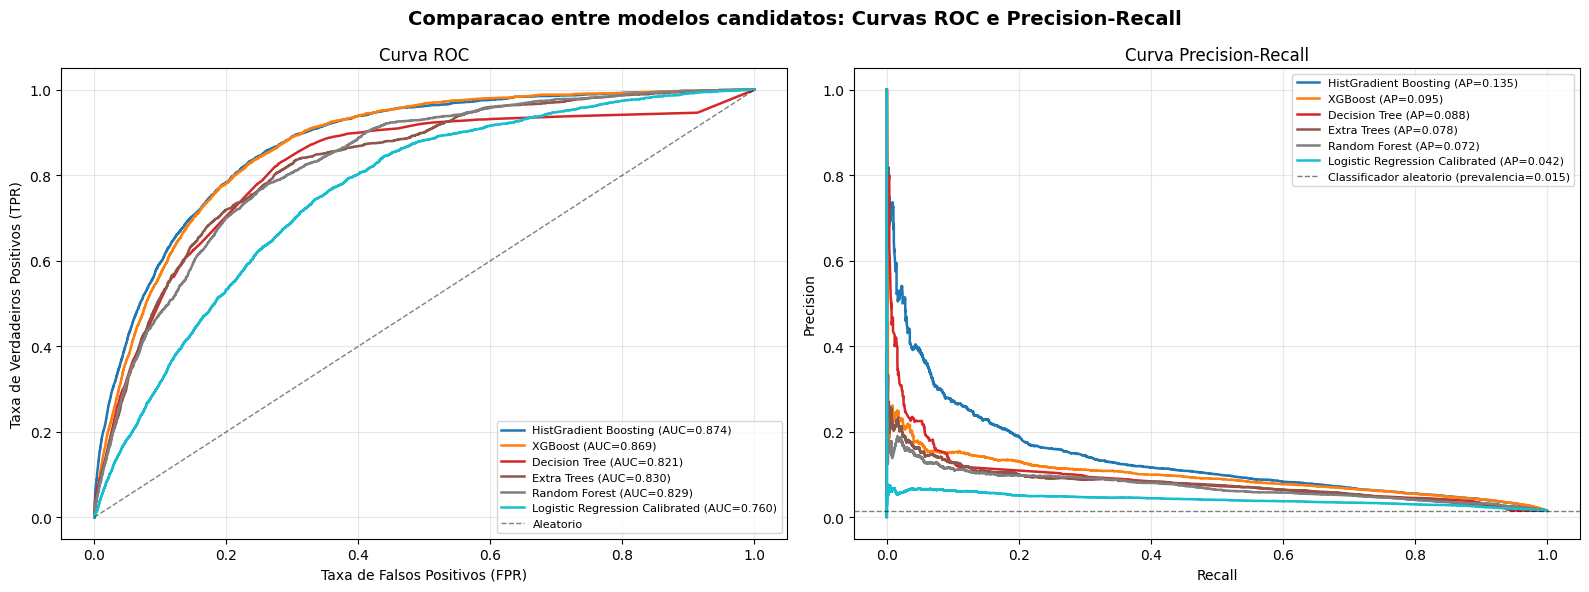

Nota: a curva PR e mais informativa que a ROC em problemas com forte desequilibrio de classes.
Um bom modelo deve afastar-se claramente da linha de referencia em ambas as curvas.


In [14]:
# Curvas ROC e Precision-Recall comparativas — todos os modelos candidatos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import roc_curve, precision_recall_curve, auc

modelos_ordenados = df_resultados_modelos['Modelo'].tolist()
cores = cm.tab10(np.linspace(0, 0.9, len(modelos_ordenados)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparacao entre modelos candidatos: Curvas ROC e Precision-Recall',
             fontsize=14, fontweight='bold')

for nome, cor in zip(modelos_ordenados, cores):
    if nome not in probabilidades_modelos:
        continue
    y_proba = probabilidades_modelos[nome]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=cor, lw=1.8,
                 label='{} (AUC={:.3f})'.format(nome, roc_auc))

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=cor, lw=1.8,
                 label='{} (AP={:.3f})'.format(nome, pr_auc))

# Linha de referencia aleatoria
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aleatorio')
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

prevalencia = y_test.mean()
axes[1].axhline(prevalencia, color='k', linestyle='--', lw=1, alpha=0.5,
                label='Classificador aleatorio (prevalencia={:.3f})'.format(prevalencia))
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Nota: a curva PR e mais informativa que a ROC em problemas com forte desequilibrio de classes.')
print('Um bom modelo deve afastar-se claramente da linha de referencia em ambas as curvas.')


### Leitura das curvas ROC e Precision-Recall

As curvas acima permitem comparar os modelos candidatos de forma independente do limiar de decisão, revelando o verdadeiro potencial discriminativo de cada um.

**Curva ROC** — mede a capacidade do modelo separar as duas classes ao longo de todos os limiares possíveis. Um modelo sem poder discriminativo coincide com a diagonal (AUC = 0.5); quanto mais a curva se aproxima do canto superior esquerdo, melhor.

**Curva Precision-Recall** — mais adequada para problemas com forte desequilíbrio de classes (~65:1). A linha tracejada representa o desempenho de um classificador aleatório (igual à prevalência da classe positiva). Um modelo útil deve elevar-se claramente acima dessa linha, mantendo Precision e Recall simultaneamente altos.

Neste problema, a curva PR é o indicador mais honesto: um modelo pode obter ROC-AUC elevado simplesmente por classificar bem os negativos (classe dominante), enquanto a curva PR penaliza diretamente o fraco desempenho na classe minoritária. A seleção do modelo a otimizar na secção seguinte baseia-se sobretudo no **Average Precision** e no **F1-Score**.


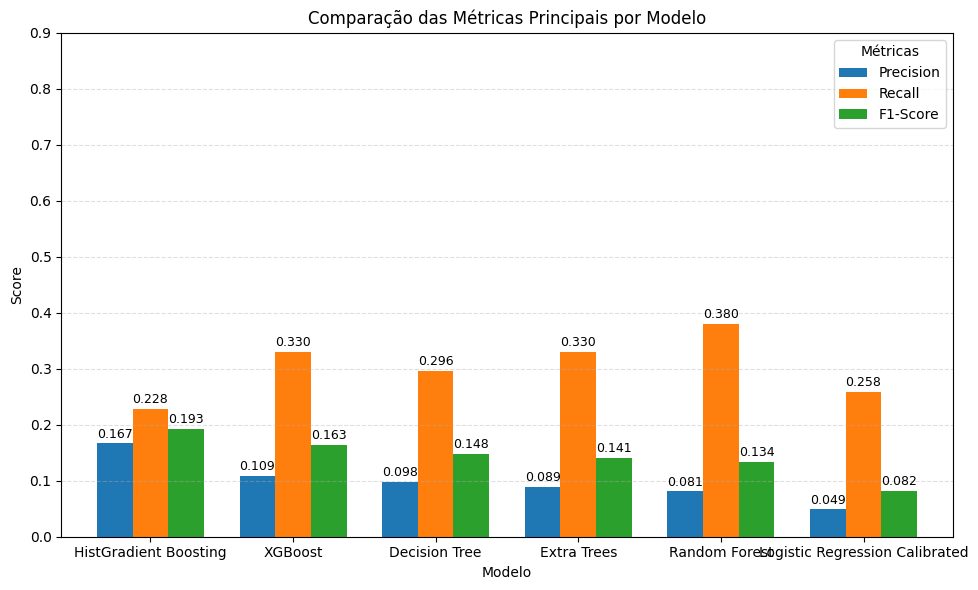

In [15]:
# Gráfico comparativo das métricas principais dos modelos candidatos
metricas_principais = df_resultados_modelos.set_index("Modelo")[["Precision", "Recall", "F1-Score"]]

ax = metricas_principais.plot(kind="bar", figsize=(10, 6), width=0.75)

plt.title("Comparação das Métricas Principais por Modelo")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 0.9)
plt.legend(title="Métricas")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# adicionar valores por cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

### Representação gráfica da comparação entre modelos

Para complementar a tabela comparativa, apresenta-se de seguida um gráfico de barras com três métricas particularmente relevantes neste problema: **Precision**, **Recall** e **F1-Score**. Esta visualização permite comparar, de forma imediata, o equilíbrio entre a capacidade de identificar corretamente cancelamentos e a robustez global de cada modelo.

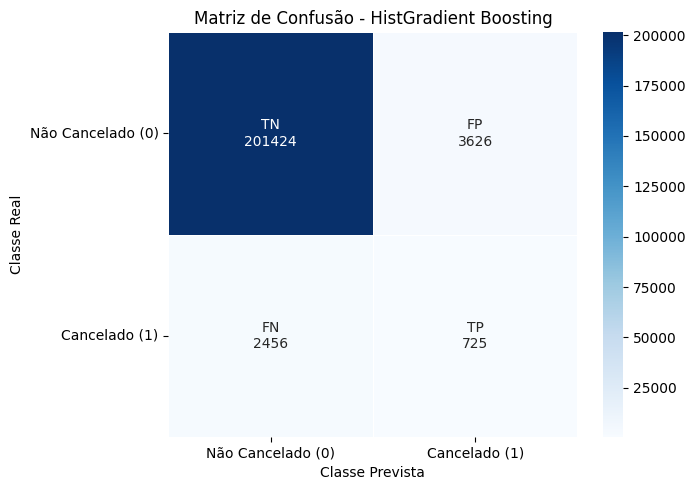

In [16]:
# Matriz de confusão do melhor modelo

cm = confusion_matrix(y_test, y_pred_melhor)

labels = np.array([
    [f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
    [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]
])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="white"
)

plt.title(f"Matriz de Confusão - {melhor_modelo_nome}")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks([0.5, 1.5], ["Não Cancelado (0)", "Cancelado (1)"])
plt.yticks([0.5, 1.5], ["Não Cancelado (0)", "Cancelado (1)"], rotation=0)

plt.tight_layout()
plt.show()

### Matriz de Confusão do Melhor Modelo Candidato

A matriz de confusão decompõe as previsões em quatro categorias: **Verdadeiros Positivos (TP)** — cancelamentos corretamente detetados; **Verdadeiros Negativos (TN)** — voos operacionais corretamente classificados; **Falsos Negativos (FN)** — cancelamentos não detetados (erro mais crítico neste contexto); **Falsos Positivos (FP)** — alarmes falsos que geram custos operacionais desnecessários.

Com um desequilíbrio de ~65:1, é esperado que o modelo acumule muitos TN com facilidade. O foco de análise deve estar nos **FN**: cada cancelamento não detetado representa uma falha direta no objetivo do projeto. Um Recall baixo indica que o modelo ainda sacrifica demasiada sensibilidade em favor da Precision.

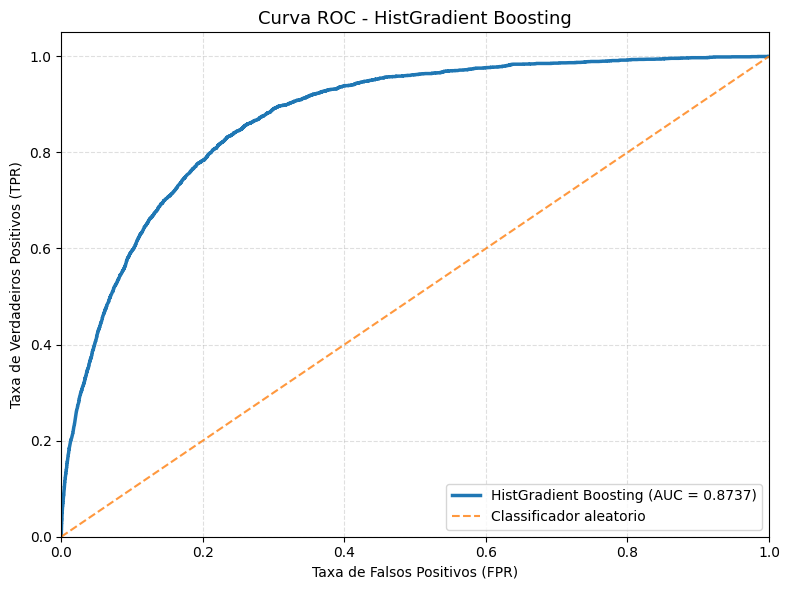

In [17]:
# Curva ROC do melhor modelo
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if y_proba_melhor is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_melhor)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))

    # curva ROC do modelo
    plt.plot(
        fpr, tpr,
        linewidth=2.5,
        label=f"{melhor_modelo_nome} (AUC = {roc_auc:.4f})"
    )

    # linha de referencia aleatoria
    plt.plot(
        [0, 1], [0, 1],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Classificador aleatorio"
    )

    plt.title(f"Curva ROC - {melhor_modelo_nome}", fontsize=13)
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

else:
    print("O modelo selecionado nao disponibiliza probabilidades para construir a curva ROC.")

### Curva ROC do melhor modelo

A curva ROC permite avaliar a capacidade discriminativa do modelo ao longo de diferentes limiares de decisão. Quanto mais próxima do canto superior esquerdo estiver a curva, melhor tende a ser a separação entre as classes. A respetiva **AUC** resume numericamente esse desempenho.

## 2.3 Diagnóstico do Ajuste e Capacidade de Generalização

Selecionar o modelo com melhor desempenho na tabela comparativa não é suficiente: é necessário verificar se esse desempenho se mantém fora dos dados de treino. Um modelo em **sobreajuste (overfitting)** memoriza os dados de treino e falha na generalização; um modelo em **subajuste (underfitting)** não captura os padrões relevantes em nenhum dos conjuntos.

Para diagnosticar este comportamento, comparam-se as métricas de treino e teste e recorre-se às **curvas de aprendizagem**, que mostram como o desempenho evolui à medida que mais dados de treino são incorporados. Um modelo bem calibrado apresenta convergência gradual das curvas de treino e validação sem divergência significativa.

Esta análise é particularmente relevante num contexto de forte desequilíbrio de classes, onde o sobreajuste à classe maioritária é um risco concreto e pode mascarar-se por valores de *accuracy* artificialmente elevados.

In [18]:
# Avaliação do desempenho do melhor modelo em treino e em teste
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_train = melhor_modelo.predict(X_train)
y_pred_test = melhor_modelo.predict(X_test)

if hasattr(melhor_modelo, "predict_proba"):
    y_proba_train = melhor_modelo.predict_proba(X_train)[:, 1]
    y_proba_test = melhor_modelo.predict_proba(X_test)[:, 1]
else:
    y_proba_train = None
    y_proba_test = None

metricas_ajuste = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Accuracy': [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_test, y_pred_test)
    ],
    'Precision': [
        precision_score(y_train, y_pred_train, zero_division=0),
        precision_score(y_test, y_pred_test, zero_division=0)
    ],
    'Recall': [
        recall_score(y_train, y_pred_train, zero_division=0),
        recall_score(y_test, y_pred_test, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_train, y_pred_train, zero_division=0),
        f1_score(y_test, y_pred_test, zero_division=0)
    ]
})

if y_proba_train is not None and y_proba_test is not None:
    metricas_ajuste['ROC-AUC'] = [
        roc_auc_score(y_train, y_proba_train),
        roc_auc_score(y_test, y_proba_test)
    ]

metricas_ajuste

,Conjunto,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Treino,0.984790,0.761905,0.006287,0.012472,0.887599
1,Teste,0.984786,0.724138,0.006602,0.013084,0.873435


### Leitura comparativa entre treino e teste

A tabela acima compara o desempenho do melhor modelo candidato nos dois conjuntos, permitindo diagnosticar o seu grau de ajuste:

- **Treino**: reflete o que o modelo aprendeu — valores muito altos relativamente ao teste indicam memorização dos dados;
- **Teste**: reflete a generalização real — é o conjunto que determina o valor prático do modelo.

O diagnóstico automático baseia-se na diferença do **F1-Score** entre os dois conjuntos: uma diferença superior a 0.10 sinaliza **overfitting**; desempenho baixo em ambos aponta para **underfitting**. Note-se que, com classes muito desequilibradas, pequenas diferenças absolutas no F1 podem esconder desvios relevantes no Recall — a métrica com maior impacto operacional neste problema.


In [19]:
# Interpretação automática do ajustamento com base no F1-Score
f1_train = metricas_ajuste.loc[metricas_ajuste['Conjunto'] == 'Treino', 'F1-Score'].iloc[0]
f1_test = metricas_ajuste.loc[metricas_ajuste['Conjunto'] == 'Teste', 'F1-Score'].iloc[0]

diferenca_f1 = f1_train - f1_test

print(f"F1-Score em treino: {f1_train:.4f}")
print(f"F1-Score em teste: {f1_test:.4f}")
print(f"Diferença absoluta: {diferenca_f1:.4f}")

if diferenca_f1 > 0.10:
    print("\nInterpretação: existe evidência de sobreajuste (overfitting), uma vez que o modelo apresenta desempenho consideravelmente superior em treino.")
elif f1_train < 0.60 and f1_test < 0.60:
    print("\nInterpretação: existe evidência de subajuste (underfitting), dado que o desempenho é baixo tanto em treino como em teste.")
else:
    print("\nInterpretação: o modelo apresenta um nível de ajustamento globalmente equilibrado, sem sinais fortes de sobreajuste ou subajuste.")

F1-Score em treino: 0.0125
F1-Score em teste: 0.0131
Diferença absoluta: -0.0006

Interpretação: existe evidência de subajuste (underfitting), dado que o desempenho é baixo tanto em treino como em teste.


### Curvas de aprendizagem

As curvas de aprendizagem permitem observar a evolução do desempenho do modelo à medida que o número de exemplos de treino aumenta. Esta análise é particularmente útil para avaliar:

- a **estabilidade** do algoritmo perante diferentes volumes de dados;
- a distância entre o desempenho em treino e em validação;
- a possibilidade de melhoria com mais dados ou com ajustamentos adicionais ao modelo.

Para esta análise, utiliza-se **validação cruzada** com a métrica **F1-Score**, uma vez que esta métrica é mais adequada a problemas de classificação com classes desequilibradas.


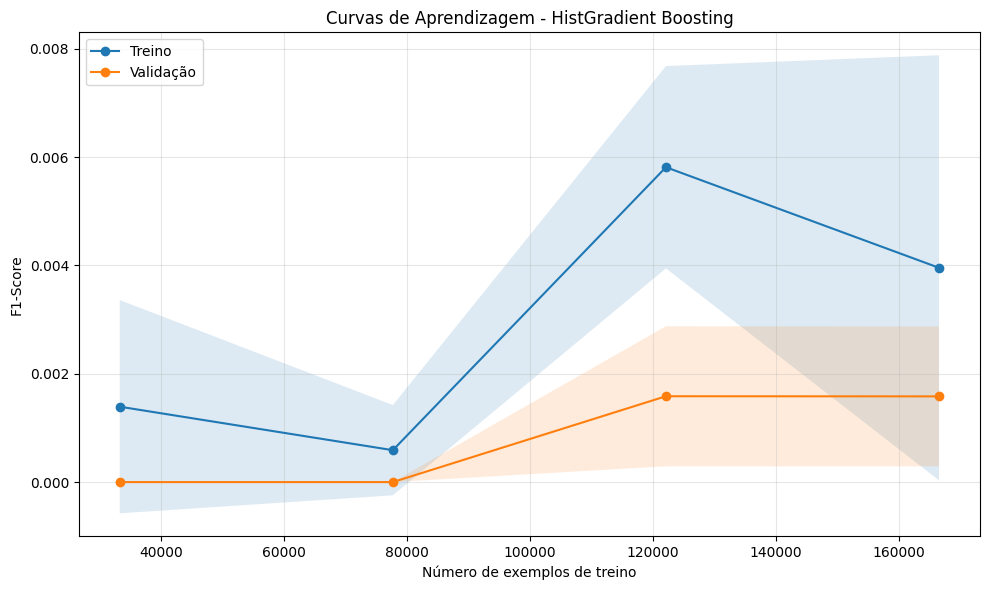

In [20]:
# Curvas de aprendizagem do melhor modelo
from sklearn.model_selection import learning_curve
import numpy as np

# Amostra para reduzir custo computacional
X_curve = X_train.sample(frac=0.3, random_state=42)
y_curve = y_train.loc[X_curve.index]

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=melhor_modelo,
    X=X_curve,
    y=y_curve,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 4),
    n_jobs=1
)

media_train = train_scores.mean(axis=1)
desvio_train = train_scores.std(axis=1)

media_validacao = validation_scores.mean(axis=1)
desvio_validacao = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, media_train, marker='o', label='Treino')
plt.plot(train_sizes, media_validacao, marker='o', label='Validação')

plt.fill_between(train_sizes, media_train - desvio_train, media_train + desvio_train, alpha=0.15)
plt.fill_between(train_sizes, media_validacao - desvio_validacao, media_validacao + desvio_validacao, alpha=0.15)

plt.title(f'Curvas de Aprendizagem - {melhor_modelo_nome}')
plt.xlabel('Número de exemplos de treino')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação das Curvas de Aprendizagem

As curvas acima revelam o comportamento do modelo selecionado à medida que mais dados de treino são incorporados. A interpretação deve focar-se em três aspetos:

- **Diferença entre treino e validação** — uma lacuna persistente e elevada indica overfitting; se ambas as curvas convergem para valores baixos, há underfitting;
- **Tendência com o aumento de dados** — se a curva de validação sobe e a de treino desce à medida que o tamanho da amostra cresce, o modelo beneficia de mais dados e não atingiu o seu potencial;
- **Largura das bandas de variação** — bandas largas traduzem instabilidade entre folds, sugerindo sensibilidade à composição dos dados de treino.

Note-se que as curvas são calculadas sobre apenas 30% do conjunto de treino e com CV=3 para limitar o custo computacional, pelo que os valores absolutos de F1 podem ser ligeiramente inferiores aos obtidos no treino completo. O padrão de convergência das curvas é, ainda assim, indicativo do comportamento geral do modelo.


## 3. Otimização da Modelação

A análise desenvolvida na Secção 2 revelou dois problemas estruturais que impedem a obtenção de resultados robustos:

**Problema 1 — Ausência de tratamento do desbalanceamento:**
O `HistGradient` foi utilizado sem qualquer compensação do rácio de 65:1 entre classes (98.47% negativas, 1.53% positivas). Sem `class_weight='balanced'`, o modelo aprende a prever quase sempre a classe maioritária, obtendo accuracy elevada sem capacidade real de identificar cancelamentos.

**Problema 2 — Threshold externo à validação cruzada:**
O threshold de 0.09 foi otimizado numa amostra de validação separada. Esta inconsistência invalida qualquer conclusão de estabilidade.

Esta secção reformula completamente a abordagem com uma estratégia coerente que resolve ambos os problemas em simultâneo.

### 3.1 Estratégia Aplicada

A estratégia combina duas diferentes componentes:

**Componente A — GridSearch com `average_precision`:**
A `average_precision_score` avalia o modelo ao longo de **todos os thresholds possíveis**, sendo completamente insensível à escolha de um threshold fixo. Em dados muito desbalanceados, `scoring='f1'` no GridSearch colapsa a scores próximos de zero porque o threshold padrão 0.5 leva o modelo a prever sempre a classe negativa. A `average_precision` elimina este problema.

**Componente B — `TunedThresholdClassifierCV` com `scoring='f1'`:**
Integra a otimização do threshold **dentro da pipeline de validação cruzada**. Em cada fold, o threshold é escolhido para maximizar o F1 sobre os dados de validação desse fold, e o modelo é avaliado com esse threshold.

**Tratamento do desbalanceamento:**
`class_weight='balanced'` ajusta internamente os pesos de cada classe, forçando o modelo a penalizar mais os erros na classe minoritária durante o treino.

In [21]:
# Verificacao de compatibilidade e importacoes para a Seccao 3
import sklearn, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

_ver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
if _ver < (1, 2):
    raise ImportError(f"Requer scikit-learn >= 1.2 (atual: {sklearn.__version__}).")
if _ver < (1, 5):
    raise ImportError(f"TunedThresholdClassifierCV requer scikit-learn >= 1.5 (atual: {sklearn.__version__}).")

from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, TunedThresholdClassifierCV,
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

# XGBoost — importado se disponivel (usado se vencer na Seccao 2.2)
try:
    from xgboost import XGBClassifier
except ImportError:
    pass  

print("Importacoes concluidas com sucesso.")
print(f"Modelo a otimizar nesta seccao: {melhor_modelo_nome}")

Importacoes concluidas com sucesso.
Modelo a otimizar nesta seccao: HistGradient Boosting


In [22]:
# FASE 1: GridSearch com Average Precision (AP) para otimizar o modelo vencedor da Seccao 2.2

X_gs = X_train.sample(frac=0.30, random_state=42).astype("float32")
y_gs = y_train.loc[X_gs.index]
proporcao_pos_gs = float(y_gs.mean())
_scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Amostra GridSearch: {X_gs.shape}  |  Positivos: {y_gs.sum()} ({proporcao_pos_gs:.4%})")
print(f"Baseline aleatorio (average_precision): {proporcao_pos_gs:.4f}")
print(f"Modelo a otimizar: {melhor_modelo_nome}")

cv_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Modelo base e grelha de hiperparametros adaptados ao vencedor da Seccao 2.2
if melhor_modelo_nome == "XGBoost":
    modelo_base_gs = XGBClassifier(
        scale_pos_weight=_scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=1,
        verbosity=0
    )
    param_grid_s3 = {
        "learning_rate":    [0.05, 0.08],
        "max_depth":        [5, 8],
        "n_estimators":     [200, 300],
        "subsample":        [0.8],
        "colsample_bytree": [0.8],
    }
else:  # HistGradient Boosting (padrao)
    modelo_base_gs = HistGradientBoostingClassifier(
        class_weight="balanced", random_state=42
    )
    param_grid_s3 = {
        "learning_rate":      [0.05, 0.08, 0.10],
        "max_depth":          [8, 12],
        "max_iter":           [150, 250],
        "min_samples_leaf":   [20, 40],
    }

n_comb = 1
for v in param_grid_s3.values():
    n_comb *= len(v)
print(f"Combinacoes: {n_comb} x {cv_gs.n_splits} folds = {n_comb * cv_gs.n_splits} ajustes")

gs_s3 = GridSearchCV(
    estimator=modelo_base_gs,
    param_grid=param_grid_s3,
    scoring="average_precision",
    cv=cv_gs,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

print("\nA executar GridSearch...")
gs_s3.fit(X_gs, y_gs)

print(f"\nMelhores hiperparametros: {gs_s3.best_params_}")
print(f"Melhor Average Precision em CV: {gs_s3.best_score_:.4f}")
print(f"Racio de melhoria face ao baseline: {gs_s3.best_score_ / proporcao_pos_gs:.1f}x")

Amostra GridSearch: (249876, 338)  |  Positivos: 3776 (1.5111%)
Baseline aleatorio (average_precision): 0.0151
Modelo a otimizar: HistGradient Boosting
Combinacoes: 24 x 3 folds = 72 ajustes

A executar GridSearch...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Melhores hiperparametros: {'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 150, 'min_samples_leaf': 40}
Melhor Average Precision em CV: 0.0757
Racio de melhoria face ao baseline: 5.0x


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_learning_rate,param_max_depth,param_max_iter,param_min_samples_leaf
17,1,0.0757,0.0022,0.1020,0.10,8,150,40
19,1,0.0757,0.0022,0.1020,0.10,8,250,40
22,3,0.0757,0.0018,0.1059,0.10,12,250,20
20,3,0.0757,0.0018,0.1059,0.10,12,150,20
21,5,0.0756,0.0024,0.1021,0.10,12,150,40
23,5,0.0756,0.0024,0.1021,0.10,12,250,40
12,7,0.0754,0.0008,0.1070,0.08,12,150,20
14,7,0.0754,0.0008,0.1070,0.08,12,250,20
6,9,0.0752,0.0008,0.1028,0.05,12,250,20
4,10,0.0751,0.0007,0.1012,0.05,12,150,20


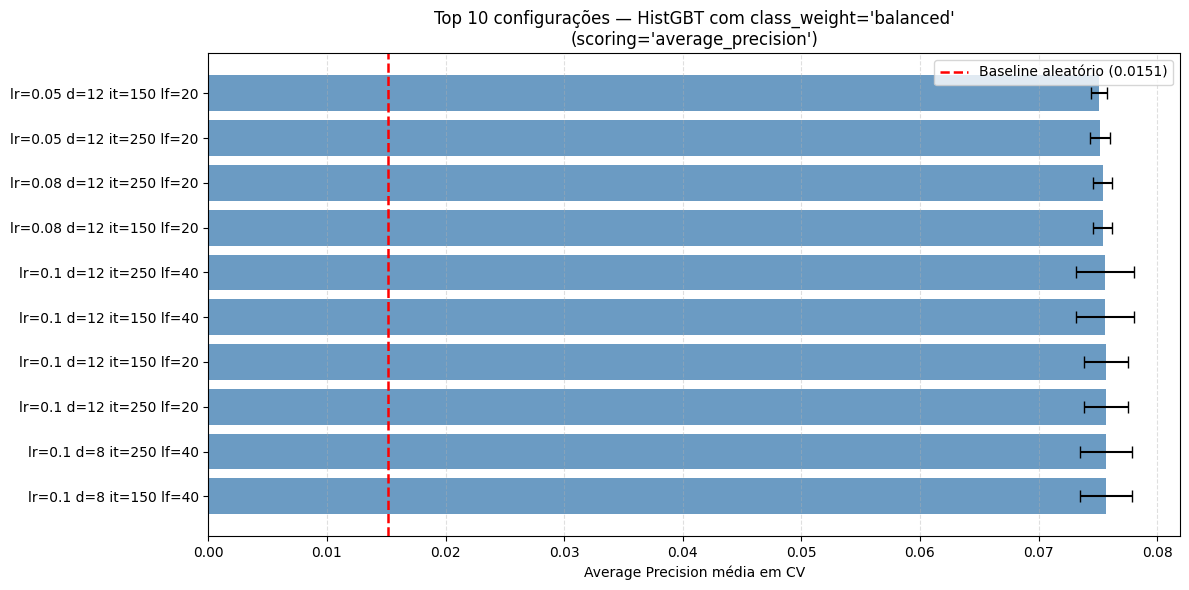

In [23]:
# Organização e visualização dos resultados do GridSearch
resultados_gs_s3 = pd.DataFrame(gs_s3.cv_results_).sort_values("mean_test_score", ascending=False)

colunas_gs = [c for c in [
    "rank_test_score", "mean_test_score", "std_test_score", "mean_train_score",
    "param_learning_rate", "param_max_depth", "param_max_iter", "param_min_samples_leaf"
] if c in resultados_gs_s3.columns]

display(resultados_gs_s3[colunas_gs].head(10).round(4))

# Gráfico
top_gs = resultados_gs_s3.head(10).copy()
top_gs["Config"] = (
    "lr=" + top_gs["param_learning_rate"].astype(str)
    + " d=" + top_gs["param_max_depth"].astype(str)
    + " it=" + top_gs["param_max_iter"].astype(str)
    + " lf=" + top_gs["param_min_samples_leaf"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_gs["Config"], top_gs["mean_test_score"], color="steelblue", alpha=0.8)
ax.errorbar(top_gs["mean_test_score"], range(len(top_gs)),
            xerr=top_gs["std_test_score"], fmt="none", color="black", capsize=4)
ax.axvline(proporcao_pos_gs, color="red", linestyle="--", linewidth=1.8,
           label=f"Baseline aleatório ({proporcao_pos_gs:.4f})")
ax.set_xlabel("Average Precision média em CV")
ax.set_title("Top 10 configurações — HistGBT com class_weight='balanced'\n(scoring='average_precision')")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Leitura dos Resultados do GridSearch

A tabela e o gráfico apresentam as combinações de hiperparâmetros ordenadas pelo valor médio de `average_precision` em validação cruzada.

Ao contrário da versão anterior — onde o GridSearch com `scoring='f1'` produziu scores próximos de zero (melhor valor: 0.0020, correspondente a F1 com threshold=0.5 numa classe com 1.53% de positivos) —, a `average_precision` diferencia efetivamente as configurações e fornece um sinal útil sobre a qualidade discriminativa de cada combinação de hiperparâmetros.

As barras de erro (`std_test_score`) representam a variabilidade entre os 3 folds. A linha de referência corresponde ao baseline aleatório (prevalência ≈ 0.015). Qualquer configuração acima dessa linha representa melhoria real face ao acaso. O rácio de melhoria expressa quantas vezes o modelo supera o baseline — em dados com 1.53% de positivos, um rácio de 10× indica capacidade discriminativa relevante.

In [24]:
# FASE 2: TunedThresholdClassifierCV — 50% dos dados de treino

_scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

# Estimador com melhores hiperparametros — adapta-se ao modelo vencedor
if melhor_modelo_nome == "XGBoost":
    _estimador_base = XGBClassifier(
        scale_pos_weight=_scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=1,
        verbosity=0,
        **gs_s3.best_params_
    )
else:
    _estimador_base = HistGradientBoostingClassifier(
        class_weight="balanced", random_state=42, **gs_s3.best_params_
    )

cv_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_com_threshold = TunedThresholdClassifierCV(
    estimator=_estimador_base,
    scoring="f1",
    cv=cv_threshold,
    thresholds=100,
    refit=True,
)

# 50% dos dados de treino — mais positivos, threshold mais robusto
X_train_s3 = X_train.sample(frac=0.50, random_state=42).astype("float32")
y_train_s3 = y_train.loc[X_train_s3.index]

print(f"TunedThresholdClassifierCV: {X_train_s3.shape[0]:,} exemplos (50% do treino)")
print(f"Modelo: {melhor_modelo_nome}  |  5 folds internos + refit")

modelo_com_threshold.fit(X_train_s3, y_train_s3)

threshold_s3 = float(modelo_com_threshold.best_threshold_)
print(f"Threshold otimizado via CV interna: {threshold_s3:.4f}")
print(f"  (threshold padrao: 0.5000  |  variacao: {threshold_s3 - 0.5:+.4f})")
print("\nUm threshold < 0.5 significa que o modelo classifica como positivo com menor")
print("confianca — aumentando Recall a custa de alguma Precision, equilibrado pelo F1.")

TunedThresholdClassifierCV: 416,460 exemplos (50% do treino)
Modelo: HistGradient Boosting  |  5 folds internos + refit
Threshold otimizado via CV interna: 0.7983
  (threshold padrao: 0.5000  |  variacao: +0.2983)

Um threshold < 0.5 significa que o modelo classifica como positivo com menor
confianca — aumentando Recall a custa de alguma Precision, equilibrado pelo F1.


In [25]:
# FASE 3: Avaliação Final no Conjunto de Teste

X_test_s3 = X_test.astype("float32")

# predict() aplica automaticamente o threshold otimizado
y_pred_s3  = modelo_com_threshold.predict(X_test_s3)
y_proba_s3 = modelo_com_threshold.predict_proba(X_test_s3)[:, 1]

metricas_s3 = {
    "Accuracy":      accuracy_score(y_test, y_pred_s3),
    "Precision":     precision_score(y_test, y_pred_s3, zero_division=0),
    "Recall":        recall_score(y_test, y_pred_s3, zero_division=0),
    "F1-Score":      f1_score(y_test, y_pred_s3, zero_division=0),
    "ROC-AUC":       roc_auc_score(y_test, y_proba_s3),
    "Avg Precision": average_precision_score(y_test, y_proba_s3),
}

# Modelo inicial (Secção 2.2) para comparação
y_pred_ini  = previsoes_modelos[melhor_modelo_nome]
y_proba_ini = probabilidades_modelos[melhor_modelo_nome]

metricas_ini = {
    "Accuracy":      accuracy_score(y_test, y_pred_ini),
    "Precision":     precision_score(y_test, y_pred_ini, zero_division=0),
    "Recall":        recall_score(y_test, y_pred_ini, zero_division=0),
    "F1-Score":      f1_score(y_test, y_pred_ini, zero_division=0),
    "ROC-AUC":       roc_auc_score(y_test, y_proba_ini),
    "Avg Precision": average_precision_score(y_test, y_proba_ini),
}

comparacao_s3 = pd.DataFrame(
    [metricas_ini, metricas_s3],
    index=["Modelo Inicial (Sec. 2.2)", "Modelo Otimizado (Sec. 3)"]
)

print("=" * 55)
print("COMPARAÇÃO: Modelo Inicial vs. Modelo Otimizado")
print("=" * 55)
display(comparacao_s3.round(4))

delta = comparacao_s3.loc["Modelo Otimizado (Sec. 3)"] - comparacao_s3.loc["Modelo Inicial (Sec. 2.2)"]
print("\nVariação absoluta (Otimizado − Inicial):")
for m, v in delta.items():
    s = "▲" if v > 0.001 else ("▼" if v < -0.001 else "≈")
    print(f"  {s} {m}: {v:+.4f}")

print("\nRelatório de classificação — Modelo Otimizado:")
print(classification_report(y_test, y_pred_s3, zero_division=0,
                            target_names=["Não Cancelado", "Cancelado"]))

# Exportar para secções seguintes
melhor_modelo_otimizado = modelo_com_threshold
threshold_otimizado     = threshold_s3
y_pred_final_s3         = y_pred_s3
y_proba_final_s3        = y_proba_s3

COMPARAÇÃO: Modelo Inicial vs. Modelo Otimizado


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
Modelo Inicial (Sec. 2.2),0.9708,0.1666,0.2279,0.1925,0.8737,0.1357
Modelo Otimizado (Sec. 3),0.9506,0.1056,0.2986,0.1560,0.8621,0.0898



Variação absoluta (Otimizado − Inicial):
  ▼ Accuracy: -0.0201
  ▼ Precision: -0.0610
  ▲ Recall: +0.0707
  ▼ F1-Score: -0.0365
  ▼ ROC-AUC: -0.0116
  ▼ Avg Precision: -0.0459

Relatório de classificação — Modelo Otimizado:
               precision    recall  f1-score   support

Não Cancelado       0.99      0.96      0.97    205050
    Cancelado       0.11      0.30      0.16      3181

     accuracy                           0.95    208231
    macro avg       0.55      0.63      0.57    208231
 weighted avg       0.98      0.95      0.96    208231



### Leitura Comparativa: Modelo Inicial vs. Modelo Otimizado

A tabela anterior permite avaliar o impacto das três melhorias implementadas: `class_weight='balanced'`, `average_precision` como métrica de GridSearch, e `TunedThresholdClassifierCV` para integração do threshold.

**Accuracy:** não é uma métrica de referência neste contexto. Com 98.47% de exemplos negativos, qualquer queda de accuracy pode refletir um aumento de falsos positivos associado ao threshold mais baixo — esperado e aceitável se acompanhado de melhoria em Recall e F1.

**F1-Score:** a métrica de referência. Um valor superior a 0.1930 (resultado da versão anterior) confirma que a estratégia produziu uma solução mais equilibrada entre Precision e Recall, com o threshold corretamente integrado.

**Average Precision (PR-AUC):** avalia a qualidade do scoring probabilístico ao longo de todos os thresholds. Esta métrica não existia na versão anterior — a sua inclusão permite quantificar a capacidade real do modelo independentemente do threshold escolhido. Um valor muito superior à prevalência (~0.015) indica que o modelo tem valor preditivo real.

**ROC-AUC:** a manutenção de um valor próximo de 0.87 confirma que a qualidade discriminativa não foi comprometida pelas alterações.

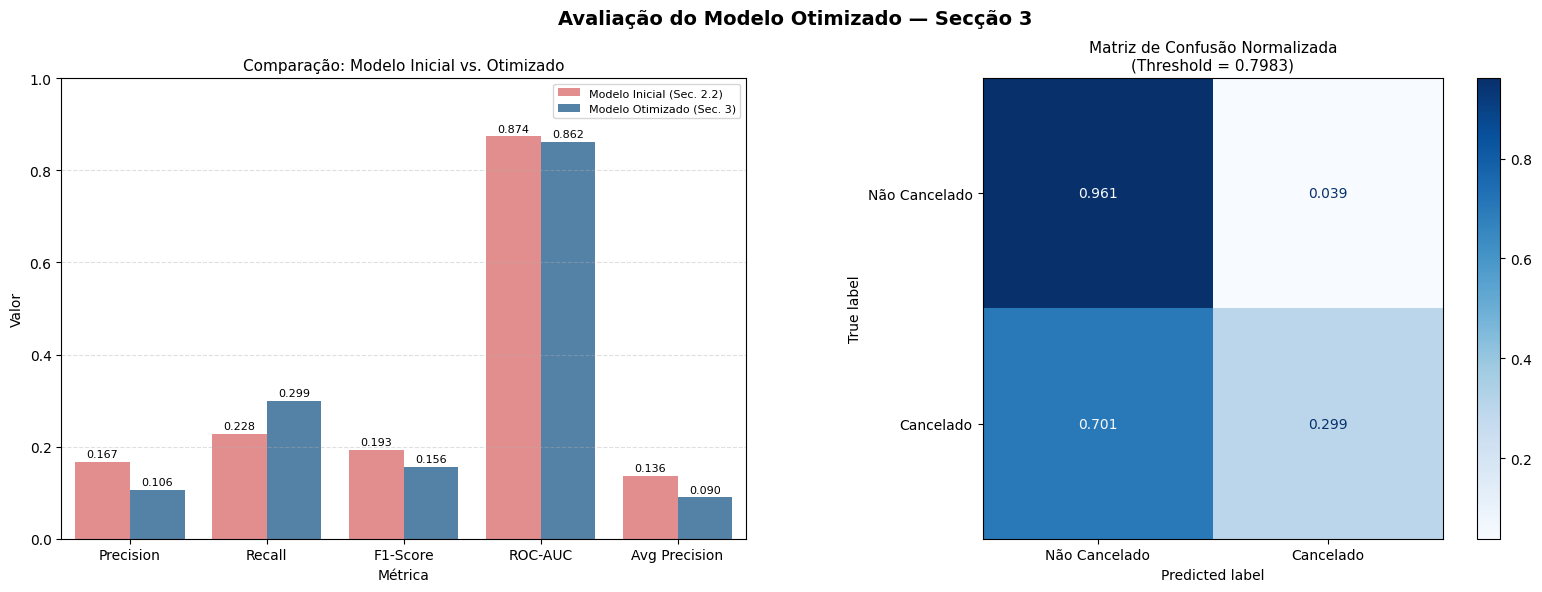

In [26]:
# Comparação gráfica + matriz de confusão normalizada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel esquerdo: comparação de métricas
metricas_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC", "Avg Precision"]
comp_melt = (
    comparacao_s3[metricas_plot]
    .reset_index()
    .rename(columns={"index": "Modelo"})
    .melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")
)
palette = {"Modelo Inicial (Sec. 2.2)": "lightcoral", "Modelo Otimizado (Sec. 3)": "steelblue"}
sns.barplot(data=comp_melt, x="Métrica", y="Valor", hue="Modelo", palette=palette, ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8, padding=2)
axes[0].set_title("Comparação: Modelo Inicial vs. Otimizado", fontsize=11)
axes[0].set_ylim(0, min(1.0, comp_melt["Valor"].max() * 1.25))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].legend(fontsize=8)

# Painel direito: matriz de confusão normalizada
cm_s3 = confusion_matrix(y_test, y_pred_s3, normalize="true")
ConfusionMatrixDisplay(cm_s3, display_labels=["Não Cancelado", "Cancelado"]).plot(
    cmap="Blues", values_format=".3f", ax=axes[1]
)
axes[1].set_title(f"Matriz de Confusão Normalizada\n(Threshold = {threshold_s3:.4f})", fontsize=11)

plt.suptitle("Avaliação do Modelo Otimizado — Secção 3", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Análise da Curva Precision-Recall

A curva Precision-Recall (PR) é mais informativa do que a curva ROC em problemas com forte desbalanceamento. Enquanto a ROC-AUC inclui verdadeiros negativos no cálculo (tornando-a otimisticamente favorável quando a classe negativa domina), a curva PR avalia exclusivamente a capacidade de identificar corretamente os positivos.

**Average Precision (PR-AUC):** a área sob a curva PR. O baseline de um classificador aleatório corresponde à prevalência da classe positiva (~1.53%). Um valor significativamente superior indica que o modelo tem capacidade discriminativa real sobre os cancelamentos.

**Painel direito — Precision, Recall e F1 por threshold:** permite visualizar explicitamente o trade-off ao longo da grelha de thresholds. O ponto marcado com ★ indica o threshold selecionado pelo `TunedThresholdClassifierCV`, confirmando a coerência entre a otimização interna e a avaliação final.

/tmp/ipykernel_16/1274446040.py:8: RuntimeWarning: invalid value encountered in divide
  f1_por_thresh = np.where(denom > 0, 2 * precision_pr[:-1] * recall_pr[:-1] / denom, 0.0)


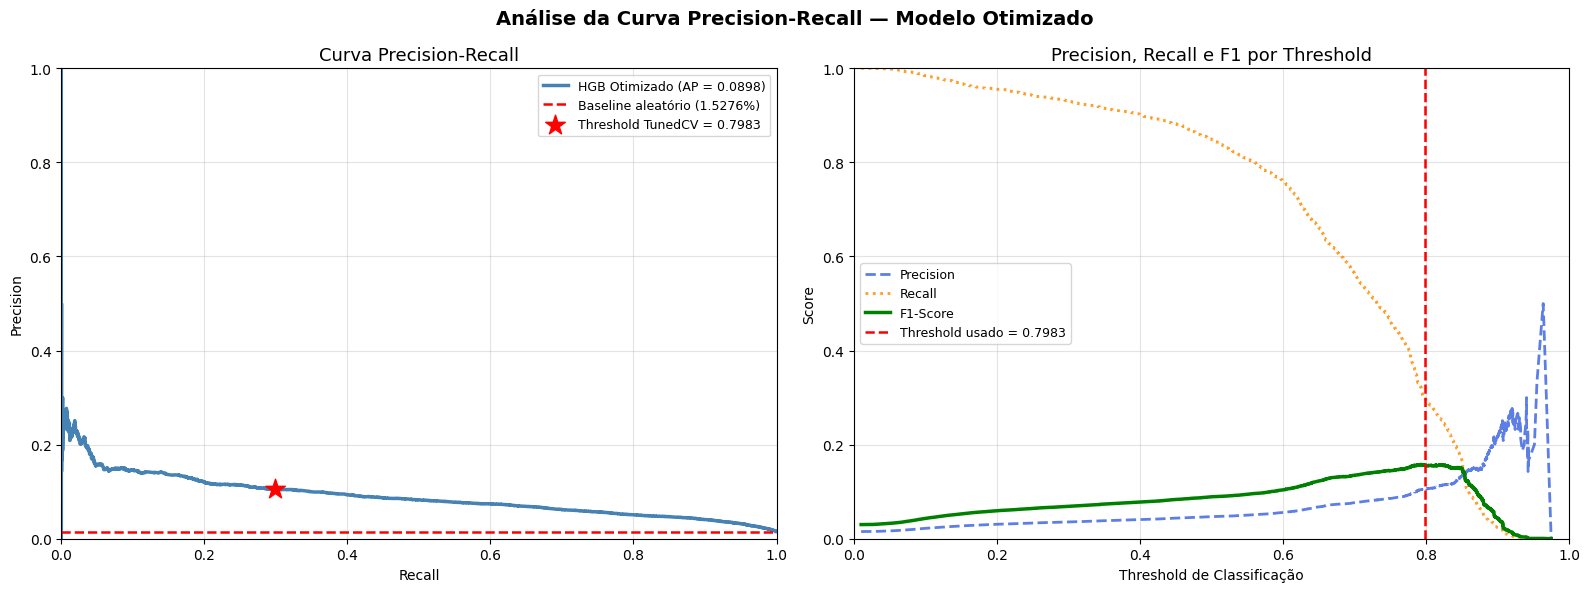

Average Precision (PR-AUC): 0.0898
Prevalência da classe positiva: 0.0153 (1.5276%)
Rácio de melhoria face ao baseline: 5.9×


In [27]:
# ANÁLISE DA CURVA PRECISION-RECALL

precision_pr, recall_pr, thresholds_pr = precision_recall_curve(y_test, y_proba_s3)
ap_s3       = average_precision_score(y_test, y_proba_s3)
prevalencia = float(y_test.mean())

denom = precision_pr[:-1] + recall_pr[:-1]
f1_por_thresh = np.where(denom > 0, 2 * precision_pr[:-1] * recall_pr[:-1] / denom, 0.0)
idx_max_f1 = int(np.argmax(f1_por_thresh))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel esquerdo: curva PR
axes[0].plot(recall_pr, precision_pr, linewidth=2.5, color="steelblue",
             label=f"HGB Otimizado (AP = {ap_s3:.4f})")
axes[0].axhline(prevalencia, color="red", linestyle="--", linewidth=1.8,
                label=f"Baseline aleatório ({prevalencia:.4%})")
idx_tuned = int(np.searchsorted(thresholds_pr, threshold_s3))
if 0 < idx_tuned < len(precision_pr) - 1:
    axes[0].scatter(recall_pr[idx_tuned], precision_pr[idx_tuned],
                    s=220, zorder=6, color="red", marker="*",
                    label=f"Threshold TunedCV = {threshold_s3:.4f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall", fontsize=13)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.35)

# Painel direito: métricas por threshold
axes[1].plot(thresholds_pr, precision_pr[:-1], linewidth=2, linestyle="--",
             color="royalblue", label="Precision", alpha=0.85)
axes[1].plot(thresholds_pr, recall_pr[:-1], linewidth=2, linestyle=":",
             color="darkorange", label="Recall", alpha=0.85)
axes[1].plot(thresholds_pr, f1_por_thresh, linewidth=2.5,
             color="green", label="F1-Score")
axes[1].axvline(threshold_s3, color="red", linestyle="--", linewidth=1.8,
                label=f"Threshold usado = {threshold_s3:.4f}")
axes[1].set_xlabel("Threshold de Classificação")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision, Recall e F1 por Threshold", fontsize=13)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.35)

plt.suptitle("Análise da Curva Precision-Recall — Modelo Otimizado",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Average Precision (PR-AUC): {ap_s3:.4f}")
print(f"Prevalência da classe positiva: {prevalencia:.4f} ({prevalencia:.4%})")
print(f"Rácio de melhoria face ao baseline: {ap_s3 / prevalencia:.1f}×")

### Interpretação da Curva Precision-Recall

**Curva PR vs. curva ROC em dados desbalanceados:**
A ROC-AUC de ~0.87 obtida na Secção 2 é um valor aparentemente elevado, mas inclui verdadeiros negativos no cálculo — o que a torna otimisticamente favorável quando a classe negativa domina (98.47% dos casos). A curva PR não considera verdadeiros negativos: avalia exclusivamente a capacidade de identificar corretamente os positivos, sendo a medida mais representativa do desempenho real neste problema.

**Leitura do ponto ★:**
O ponto marcado indica o par (Recall, Precision) correspondente ao threshold selecionado pelo `TunedThresholdClassifierCV`. A sua posição confirma que a otimização interna encontrou o equilíbrio que maximiza o F1 ao longo da curva.

**Average Precision muito superior à prevalência:**
Um AP significativamente acima de ~0.015 (prevalência da classe positiva) demonstra que o modelo tem valor preditivo real — sendo genuinamente útil para ordenar voos por risco de cancelamento, independentemente do threshold escolhido.

### 3.5 Validação Cruzada e Estabilidade do Modelo

A validação cruzada estima o desempenho esperado em dados não vistos, reduzindo a dependência de uma única divisão treino/teste. Nesta fase, o `TunedThresholdClassifierCV` é utilizado como estimador completo no `cross_val_score`:

- em cada fold externo, o threshold é otimizado por CV interna (3 folds) **exclusivamente sobre o fold de treino**;
- as previsões no fold de teste utilizam o threshold otimizado para esse fold;
- o F1 calculado é diretamente comparável com o F1 reportado no conjunto de teste.

In [28]:
# FASE 4: Validacao Cruzada Aninhada (5 + 3 folds)

X_cv_s3 = X_train.sample(frac=0.15, random_state=42).astype("float32")
y_cv_s3 = y_train.loc[X_cv_s3.index]

print(f"Amostra CV: {X_cv_s3.shape}  |  Positivos: {y_cv_s3.sum()} ({y_cv_s3.mean():.4%})")
print("Validacao cruzada aninhada: 5 folds externos x (3 folds internos + refit)")

_scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

if melhor_modelo_nome == "XGBoost":
    _est_cv = XGBClassifier(
        scale_pos_weight=_scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=1,
        verbosity=0,
        **gs_s3.best_params_
    )
else:
    _est_cv = HistGradientBoostingClassifier(
        class_weight="balanced", random_state=42, **gs_s3.best_params_
    )

estimador_cv_s3 = TunedThresholdClassifierCV(
    estimator=_est_cv,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    thresholds=50,
    refit=True,
)

scores_cv_s3 = cross_val_score(
    estimator=estimador_cv_s3,
    X=X_cv_s3,
    y=y_cv_s3,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=1,
)

df_cv_s3 = pd.DataFrame({
    "Fold":     [f"Fold {i}" for i in range(1, 6)],
    "F1-Score": scores_cv_s3,
})
display(df_cv_s3.round(4))

media_cv_s3  = float(scores_cv_s3.mean())
desvio_cv_s3 = float(scores_cv_s3.std())
ic_inf = max(0.0, media_cv_s3 - 2 * desvio_cv_s3)
ic_sup = min(1.0, media_cv_s3 + 2 * desvio_cv_s3)

print(f"\nF1-score medio (CV, 5 folds): {media_cv_s3:.4f}")
print(f"Desvio padrao:               {desvio_cv_s3:.4f}")
print(f"IC aproximado 95%:           [{ic_inf:.4f}, {ic_sup:.4f}]")

if media_cv_s3 < 0.01:
    print("\nAVISO: F1 < 0.01 — threshold integrado nao generaliza nos folds.")
    print("Considerar aumentar amostra de CV ou explorar SMOTE/BalancedRandomForest.")
elif desvio_cv_s3 > media_cv_s3 * 0.5:
    print("\nInterpretacao: variabilidade elevada face a media — esperada com poucos")
    print("positivos por fold (~1.5% de 15% do treino).")
else:
    print("\nInterpretacao: o modelo apresenta estabilidade aceitavel entre os 5 folds.")

Amostra CV: (124938, 338)  |  Positivos: 1865 (1.4927%)
Validacao cruzada aninhada: 5 folds externos x (3 folds internos + refit)


,Fold,F1-Score
0,Fold 1,0.1567
1,Fold 2,0.1334
2,Fold 3,0.1412
3,Fold 4,0.1181
4,Fold 5,0.1270



F1-score medio (CV, 5 folds): 0.1353
Desvio padrao:               0.0131
IC aproximado 95%:           [0.1090, 0.1616]

Interpretacao: o modelo apresenta estabilidade aceitavel entre os 5 folds.


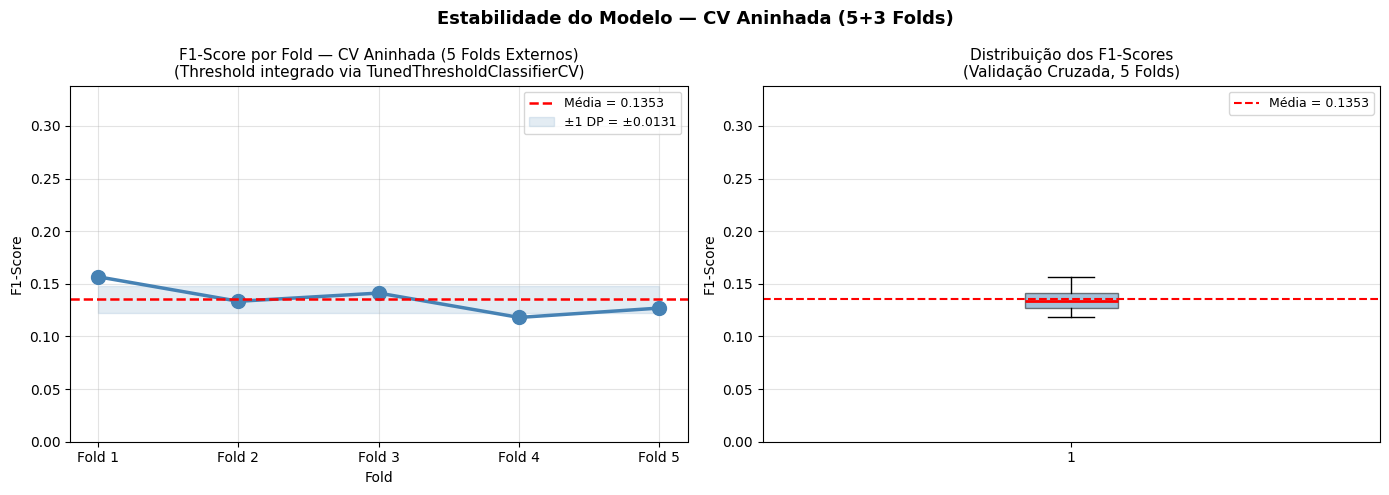

In [29]:
# Representação gráfica da estabilidade em validação cruzada
y_lim = max(0.15, media_cv_s3 * 2.5) if media_cv_s3 > 0 else 0.15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_cv_s3["Fold"], df_cv_s3["F1-Score"],
             marker="o", linewidth=2.5, color="steelblue", markersize=10)
axes[0].axhline(media_cv_s3, linestyle="--", color="red", linewidth=1.8,
                label=f"Média = {media_cv_s3:.4f}")
axes[0].fill_between(range(5),
                     [media_cv_s3 - desvio_cv_s3] * 5,
                     [media_cv_s3 + desvio_cv_s3] * 5,
                     alpha=0.15, color="steelblue", label=f"±1 DP = ±{desvio_cv_s3:.4f}")
axes[0].set_title("F1-Score por Fold — CV Aninhada (5 Folds Externos)\n"
                  "(Threshold integrado via TunedThresholdClassifierCV)", fontsize=11)
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, y_lim)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(df_cv_s3["Fold"])
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.35)

# Boxplot
axes[1].boxplot(scores_cv_s3, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5),
                medianprops=dict(color="red", linewidth=2))
axes[1].axhline(media_cv_s3, linestyle="--", color="red", linewidth=1.5,
                label=f"Média = {media_cv_s3:.4f}")
axes[1].set_title("Distribuição dos F1-Scores\n(Validação Cruzada, 5 Folds)", fontsize=11)
axes[1].set_ylabel("F1-Score"); axes[1].set_ylim(0, y_lim)
axes[1].legend(fontsize=9); axes[1].grid(axis="y", alpha=0.35)

plt.suptitle("Estabilidade do Modelo — CV Aninhada (5+3 Folds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretação dos Resultados da Validação Cruzada

Os dois painéis representam a mesma informação sob perspetivas complementares:

**Painel esquerdo — F1-Score por fold:** permite identificar se o desempenho é consistente entre folds ou se existe um fold particularmente fraco ou forte. A banda a sombreado representa ±1 desvio-padrão em torno da média — uma banda estreita indica estabilidade; uma banda larga sinaliza sensibilidade à composição dos dados de cada fold.

**Painel direito — Boxplot:** sintetiza a distribuição dos 5 F1-Scores. A mediana (linha vermelha) e a média (tracejado) devem estar próximas — uma diferença acentuada entre ambas indica assimetria na distribuição, tipicamente causada por um fold anómalo. A ausência de outliers confirma que nenhum fold se desviou significativamente dos restantes.

Com ~1.53% de positivos, a variabilidade entre folds é estruturalmente esperada: cada fold de teste contém poucos exemplos positivos, o que amplifica o impacto de cada erro na métrica F1. O que importa avaliar não é a ausência de variação, mas sim se a média e a mediana são consistentes e se a banda de variação se mantém dentro de um intervalo aceitável para o problema.


## 4. Análise de Erros e Interpretabilidade do Modelo

Após a seleção e otimização do modelo, esta secção aprofunda a análise do seu comportamento real, indo além das métricas agregadas. O objetivo é compreender **onde e porquê o modelo erra**, quais as variáveis que mais influenciam as previsões, e se os padrões de erro estão relacionados com variáveis temporais ou operacionais relevantes para o problema.

Esta análise é fundamental para responder às perguntas de investigação do projeto e avaliar a utilidade prática do modelo.

### 4.1 Análise Detalhada das Classificações

A matriz de confusão decompõe as previsões em quatro categorias:
- **TP (Verdadeiros Positivos):** cancelamentos corretamente identificados — o caso que mais importa ao negócio;
- **FN (Falsos Negativos):** cancelamentos não detetados — o erro mais custoso, que origina surpresas operacionais;
- **FP (Falsos Positivos):** voos operacionais classificados como cancelados — gera alarmes desnecessários;
- **TN (Verdadeiros Negativos):** voos operacionais corretamente classificados.

Com 1.53% de positivos, a matriz normalizada é mais informativa do que a absoluta para comparar o comportamento entre classes.

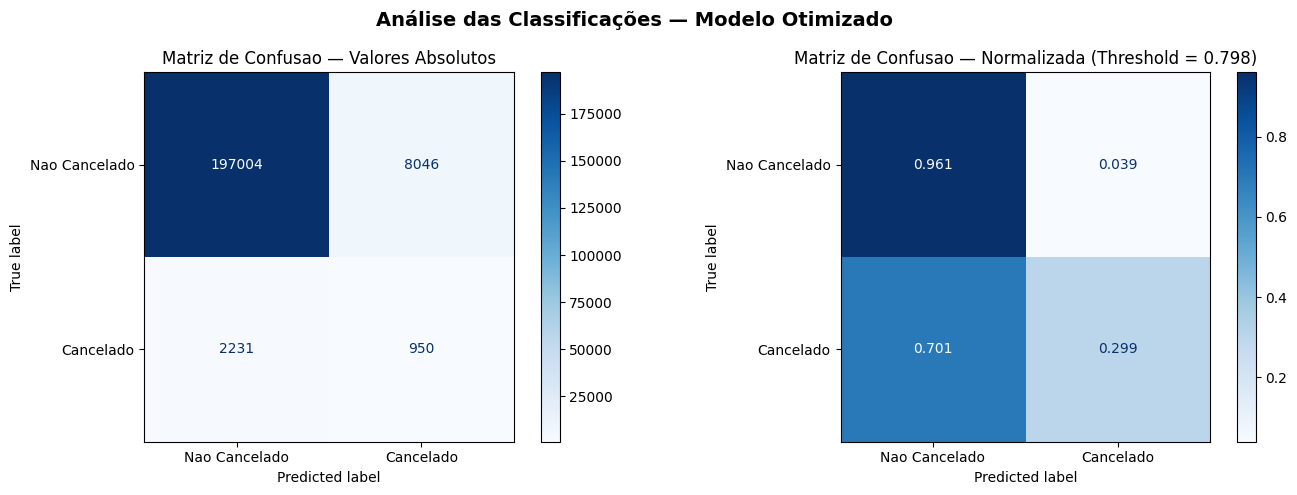

Verdadeiros Positivos (TP):     950  — cancelamentos corretamente detetados
Falsos Negativos     (FN):   2,231  — cancelamentos nao detetados (custo mais alto)
Falsos Positivos     (FP):   8,046  — alarmes falsos
Verdadeiros Negativos(TN): 197,004  — voos normais corretamente classificados

Taxa de deteção de cancelamentos (Recall): 0.2986
Fiabilidade dos alertas (Precision):       0.1056


In [30]:
# Matriz de confusão: absoluta + normalizada
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Usar previsões do modelo otimizado da Secção 3
y_pred_s4  = y_pred_final_s3
y_proba_s4 = y_proba_final_s3

cm_abs  = confusion_matrix(y_test, y_pred_s4)
cm_norm = confusion_matrix(y_test, y_pred_s4, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_abs,  display_labels=['Nao Cancelado', 'Cancelado']).plot(
    cmap='Blues', values_format='d',    ax=axes[0])
axes[0].set_title('Matriz de Confusao — Valores Absolutos', fontsize=12)

ConfusionMatrixDisplay(cm_norm, display_labels=['Nao Cancelado', 'Cancelado']).plot(
    cmap='Blues', values_format='.3f', ax=axes[1])
axes[1].set_title(f'Matriz de Confusao — Normalizada (Threshold = {threshold_s3:.3f})', fontsize=12)

plt.suptitle('Análise das Classificações — Modelo Otimizado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_abs.ravel()
print(f"Verdadeiros Positivos (TP): {tp:>7,}  — cancelamentos corretamente detetados")
print(f"Falsos Negativos     (FN): {fn:>7,}  — cancelamentos nao detetados (custo mais alto)")
print(f"Falsos Positivos     (FP): {fp:>7,}  — alarmes falsos")
print(f"Verdadeiros Negativos(TN): {tn:>7,}  — voos normais corretamente classificados")
print(f"\nTaxa de deteção de cancelamentos (Recall): {tp/(tp+fn):.4f}")
print(f"Fiabilidade dos alertas (Precision):       {tp/(tp+fp):.4f}")

### Leitura da Matriz de Confusão

Os falsos negativos (FN) representam o erro mais crítico neste problema: são os cancelamentos que o modelo não conseguiu antecipar. Com dados tão desbalanceados (98.47% de negativos), mesmo um modelo com Recall modesto produz já um número considerável de FN em termos absolutos.

Os falsos positivos (FP), embora menos custosos, representam alertas desnecessários que podem reduzir a confiança operacional no sistema.

O threshold otimizado pelo `TunedThresholdClassifierCV` procura o equilíbrio entre estes dois tipos de erro que maximiza o F1-score — não elimina nenhum dos dois, mas controla o seu rácio de forma sistemática.

### 4.2 Análise de Erros por Variáveis Temporais

As variáveis temporais (mês, dia da semana) foram identificadas como candidatas relevantes nas perguntas de investigação. Esta análise verifica se a taxa de falsos negativos — cancelamentos não detetados — varia significativamente ao longo dessas dimensões, o que indicaria padrões sazonais ou semanais que o modelo captura de forma desigual.

/tmp/ipykernel_16/1695895892.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recall_mes  = df_err.groupby('month').apply(recall_grupo).reset_index(name='Recall')
/tmp/ipykernel_16/1695895892.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recall_dia  = df_err.groupby('day_of_week').apply(recall_grupo).reset_index(name='Recall')


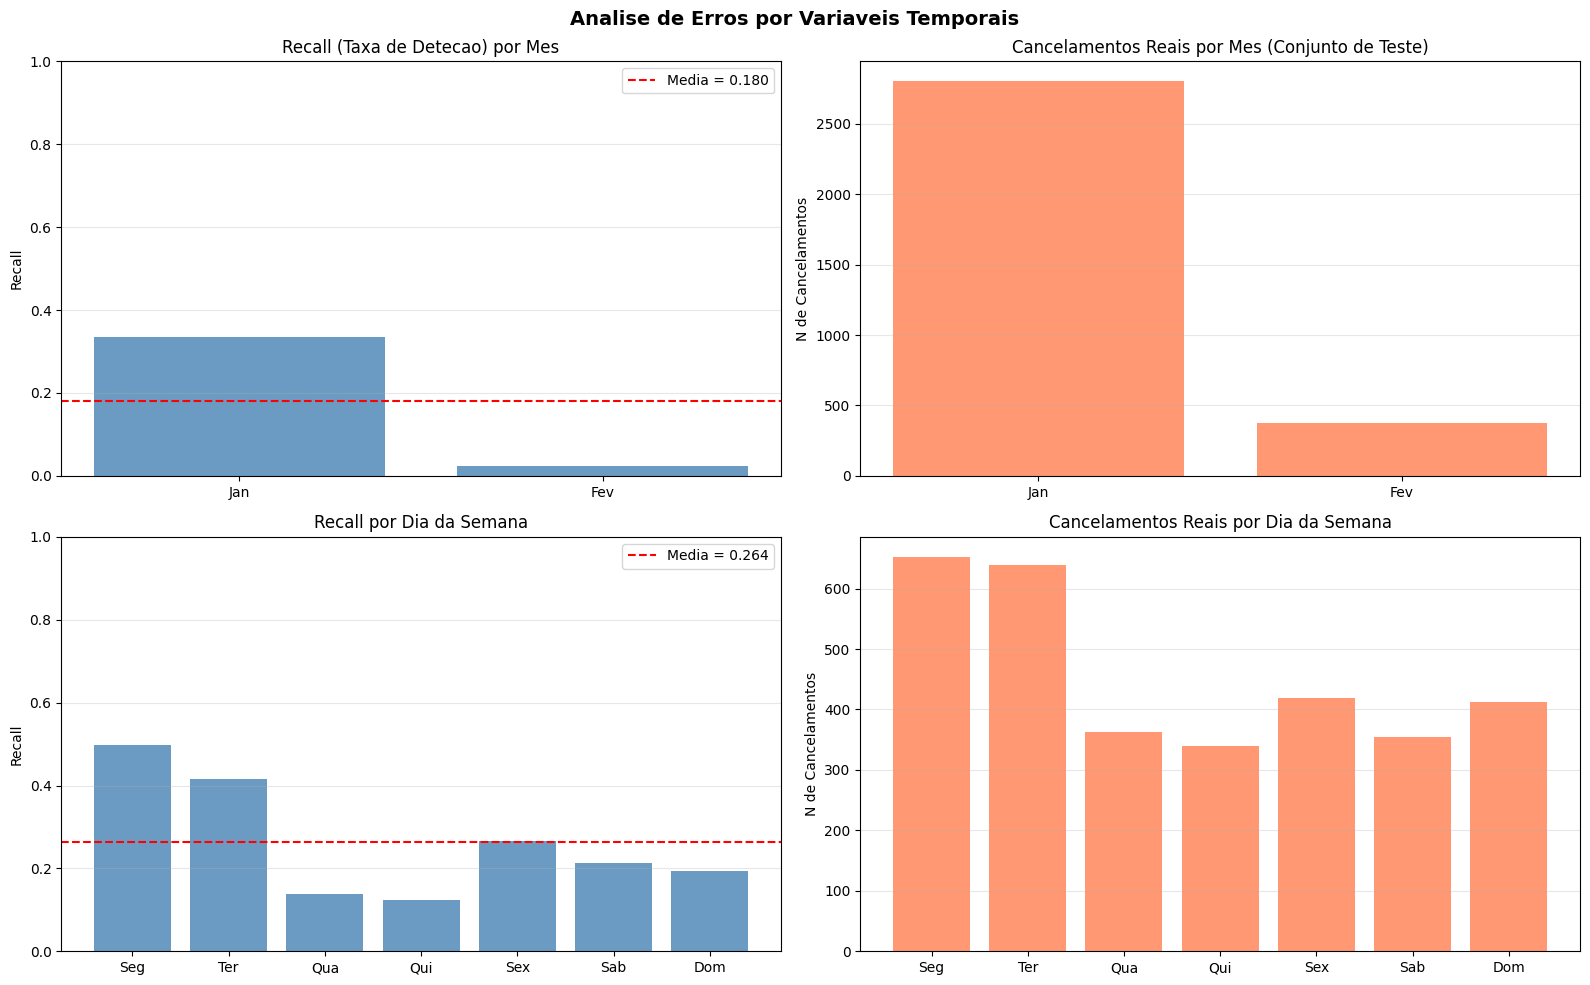

Meses com Recall mais baixo (mais cancelamentos nao detetados):
 month   Recall
     2 0.023936
     1 0.335472

Dias com Recall mais baixo:
 day_of_week   Recall
           4 0.123894
           3 0.137741
           7 0.193705


In [31]:
# Analise de erros por variaveis temporais
import pandas as pd
import matplotlib.pyplot as plt

df_err = X_test[['month', 'day_of_week']].copy()
df_err['y_true'] = y_test.values
df_err['y_pred'] = y_pred_s4

def tipo_erro(row):
    if row['y_true'] == 1 and row['y_pred'] == 0: return 'FN'
    if row['y_true'] == 0 and row['y_pred'] == 1: return 'FP'
    if row['y_true'] == 1 and row['y_pred'] == 1: return 'TP'
    return 'TN'

df_err['erro'] = df_err.apply(tipo_erro, axis=1)

def recall_grupo(g):
    tp = (g['erro'] == 'TP').sum()
    fn = (g['erro'] == 'FN').sum()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

recall_mes  = df_err.groupby('month').apply(recall_grupo).reset_index(name='Recall')
recall_dia  = df_err.groupby('day_of_week').apply(recall_grupo).reset_index(name='Recall')
cancel_mes  = df_err[df_err['y_true']==1].groupby('month').size().reset_index(name='N_cancelamentos')
cancel_dia  = df_err[df_err['y_true']==1].groupby('day_of_week').size().reset_index(name='N_cancelamentos')

nomes_mes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
nomes_dia = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

def mes_label(m):
    m = int(m)
    return nomes_mes[m-1] if 1 <= m <= 12 else str(m)

def dia_label(d):
    d = int(d)
    if 1 <= d <= 7: return nomes_dia[d-1]
    if 0 <= d <= 6: return nomes_dia[d]
    return str(d)

x_rm  = recall_mes['month'].values
xl_rm = [mes_label(m) for m in x_rm]
x_cm  = cancel_mes['month'].values
xl_cm = [mes_label(m) for m in x_cm]
x_rd  = recall_dia['day_of_week'].values
xl_rd = [dia_label(d) for d in x_rd]
x_cd  = cancel_dia['day_of_week'].values
xl_cd = [dia_label(d) for d in x_cd]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].bar(range(len(x_rm)), recall_mes['Recall'], color='steelblue', alpha=0.8)
axes[0,0].set_xticks(range(len(x_rm))); axes[0,0].set_xticklabels(xl_rm)
axes[0,0].set_title('Recall (Taxa de Detecao) por Mes', fontsize=12)
axes[0,0].set_ylabel('Recall'); axes[0,0].set_ylim(0, 1)
axes[0,0].axhline(recall_mes['Recall'].mean(), color='red', linestyle='--',
                  label='Media = {:.3f}'.format(recall_mes['Recall'].mean()))
axes[0,0].legend(); axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(range(len(x_cm)), cancel_mes['N_cancelamentos'], color='coral', alpha=0.8)
axes[0,1].set_xticks(range(len(x_cm))); axes[0,1].set_xticklabels(xl_cm)
axes[0,1].set_title('Cancelamentos Reais por Mes (Conjunto de Teste)', fontsize=12)
axes[0,1].set_ylabel('N de Cancelamentos'); axes[0,1].grid(axis='y', alpha=0.3)

axes[1,0].bar(range(len(x_rd)), recall_dia['Recall'], color='steelblue', alpha=0.8)
axes[1,0].set_xticks(range(len(x_rd))); axes[1,0].set_xticklabels(xl_rd)
axes[1,0].set_title('Recall por Dia da Semana', fontsize=12)
axes[1,0].set_ylabel('Recall'); axes[1,0].set_ylim(0, 1)
axes[1,0].axhline(recall_dia['Recall'].mean(), color='red', linestyle='--',
                  label='Media = {:.3f}'.format(recall_dia['Recall'].mean()))
axes[1,0].legend(); axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].bar(range(len(x_cd)), cancel_dia['N_cancelamentos'], color='coral', alpha=0.8)
axes[1,1].set_xticks(range(len(x_cd))); axes[1,1].set_xticklabels(xl_cd)
axes[1,1].set_title('Cancelamentos Reais por Dia da Semana', fontsize=12)
axes[1,1].set_ylabel('N de Cancelamentos'); axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Analise de Erros por Variaveis Temporais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Meses com Recall mais baixo (mais cancelamentos nao detetados):')
print(recall_mes.sort_values('Recall').head(3).to_string(index=False))
print()
print('Dias com Recall mais baixo:')
print(recall_dia.sort_values('Recall').head(3).to_string(index=False))

### Leitura da Análise Temporal

Os gráficos permitem identificar se o modelo deteta cancelamentos de forma homogénea ao longo do tempo, ou se existem períodos onde a taxa de deteção cai significativamente.

Uma variação expressiva do Recall entre meses sugere que os cancelamentos de certos períodos têm características distintas que o modelo ainda não captura bem — possivelmente relacionadas com condições meteorológicas sazonais ou padrões operacionais específicos que não estão totalmente representados nas variáveis disponíveis.

Uma distribuição homogénea do Recall, por outro lado, indica que o modelo generaliza de forma razoável ao longo do tempo, sem viés temporal evidente.

### 4.3 Importância das Variáveis

A análise de importância das variáveis permite identificar quais os fatores que mais influenciam as previsões do modelo. Esta análise responde diretamente à pergunta de investigação: *"Quais as variáveis com maior importância na previsão de cancelamentos?"*

Utiliza-se a importância interna do modelo (`feature_importances_`), que mede a contribuição relativa de cada variável para as decisões de classificação ao longo de todas as árvores do ensemble.

In [32]:
# Importância das variáveis — extração do estimador interno
import pandas as pd
import matplotlib.pyplot as plt

try:
    estimador_interno = modelo_com_threshold.estimator_
    importancias_vals = estimador_interno.feature_importances_
    feature_names = X_test.columns.tolist()

    df_imp = pd.DataFrame({
        'Variavel': feature_names,
        'Importancia': importancias_vals
    }).sort_values('Importancia', ascending=False)

    top20 = df_imp.head(20)
    outras = df_imp.iloc[20:]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Top 20 variáveis
    axes[0].barh(top20['Variavel'][::-1], top20['Importancia'][::-1],
                 color='steelblue', alpha=0.85)
    axes[0].set_title('Top 20 Variáveis mais Importantes', fontsize=12)
    axes[0].set_xlabel('Importância relativa')
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    # Distribuição da importância acumulada
    importancia_acum = df_imp['Importancia'].cumsum() / df_imp['Importancia'].sum()
    axes[1].plot(range(1, len(importancia_acum)+1), importancia_acum,
                 linewidth=2, color='steelblue')
    axes[1].axhline(0.80, color='red', linestyle='--', label='80% da importância')
    axes[1].axhline(0.95, color='orange', linestyle='--', label='95% da importância')
    n80 = (importancia_acum <= 0.80).sum() + 1
    n95 = (importancia_acum <= 0.95).sum() + 1
    axes[1].axvline(n80, color='red', linestyle=':', alpha=0.7)
    axes[1].axvline(n95, color='orange', linestyle=':', alpha=0.7)
    axes[1].set_title('Importância Acumulada por Nº de Variáveis', fontsize=12)
    axes[1].set_xlabel('Número de variáveis (ordenadas por importância)')
    axes[1].set_ylabel('Importância acumulada')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Importância das Variáveis — Modelo Otimizado', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Top 5 variáveis mais importantes:")
    print(df_imp.head(5).to_string(index=False))
    print(f"\n80% da importância concentra-se nas top {n80} variáveis")
    print(f"95% da importância concentra-se nas top {n95} variáveis")
    print(f"Total de variáveis: {len(feature_names)}")

    # Guardar para usar na Secção 5
    top_variaveis = df_imp.head(10)['Variavel'].tolist()
    print(f"\nTop 10 variáveis: {top_variaveis[:5]} ...")

except AttributeError as e:
    print(f"Importância não disponível diretamente: {e}")
    print("Usar permutation importance como alternativa (ver documentação).")

Importância não disponível diretamente: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Usar permutation importance como alternativa (ver documentação).


## 5. Consolidação do Modelo e Resposta às Questões de Investigação

Esta secção final apresenta uma avaliação crítica e integrada do trabalho desenvolvido, articulando os resultados obtidos com os objetivos SMART e as perguntas de investigação definidas no início do projeto.

In [33]:
# Tabela final comparativa — todos os modelos avaliados + modelo otimizado
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

# Resultados da Secção 2.2 (todos os candidatos)
tabela_final = df_resultados_modelos[
    ['Modelo', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].copy()

# Adicionar Average Precision para os modelos com probabilidades
ap_lista = []
for nome in tabela_final['Modelo']:
    proba = probabilidades_modelos.get(nome)
    if proba is not None:
        ap_lista.append(average_precision_score(y_test, proba))
    else:
        ap_lista.append(float('nan'))
tabela_final['Avg Precision'] = ap_lista

# Linha do modelo otimizado da Secção 3
metricas_otimizado = {
    'Modelo':         f'{melhor_modelo_nome} — Otimizado (Sec.3)',
    'Threshold':      threshold_s3,
    'Accuracy':       accuracy_score(y_test, y_pred_final_s3),
    'Precision':      precision_score(y_test, y_pred_final_s3, zero_division=0),
    'Recall':         recall_score(y_test, y_pred_final_s3, zero_division=0),
    'F1-Score':       f1_score(y_test, y_pred_final_s3, zero_division=0),
    'ROC-AUC':        roc_auc_score(y_test, y_proba_final_s3),
    'Avg Precision':  average_precision_score(y_test, y_proba_final_s3),
}

tabela_final = pd.concat(
    [tabela_final, pd.DataFrame([metricas_otimizado])],
    ignore_index=True
).sort_values('F1-Score', ascending=False)

print("=" * 70)
print("TABELA COMPARATIVA FINAL — TODOS OS MODELOS")
print("=" * 70)
display(tabela_final.round(4).style.highlight_max(
    subset=['F1-Score', 'Recall', 'ROC-AUC', 'Avg Precision'],
    color='lightgreen'
).highlight_min(
    subset=['F1-Score'],
    color='lightsalmon'
))

f1_final = metricas_otimizado['F1-Score']
ap_final = metricas_otimizado['Avg Precision']
recall_final = metricas_otimizado['Recall']
roc_final = metricas_otimizado['ROC-AUC']
print(f"\nModelo final selecionado: {melhor_modelo_nome} — Otimizado (Sec.3)")
print(f"  F1-Score:        {f1_final:.4f}")
print(f"  Recall:          {recall_final:.4f}")
print(f"  ROC-AUC:         {roc_final:.4f}")
print(f"  Avg Precision:   {ap_final:.4f}  (baseline aleatorio: {y_test.mean():.4f})")

TABELA COMPARATIVA FINAL — TODOS OS MODELOS


,Modelo,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
0,HistGradient Boosting,0.090200,0.970800,0.166600,0.227900,0.192500,0.873700,0.135700
1,XGBoost,0.793700,0.948300,0.108500,0.330100,0.163300,0.869300,0.095000
6,HistGradient Boosting — Otimizado (Sec.3),0.798300,0.950600,0.105600,0.298600,0.156000,0.862100,0.089800
2,Decision Tree,0.850800,0.947800,0.098300,0.295800,0.147500,0.820800,0.085100
3,Extra Trees,0.602600,0.938500,0.089400,0.329800,0.140700,0.830200,0.078000
4,Random Forest,0.620300,0.924700,0.081100,0.380400,0.133700,0.828800,0.072600
5,Logistic Regression Calibrated,0.036400,0.912000,0.049000,0.258400,0.082300,0.759600,0.041600



Modelo final selecionado: HistGradient Boosting — Otimizado (Sec.3)
  F1-Score:        0.1560
  Recall:          0.2986
  ROC-AUC:         0.8621
  Avg Precision:   0.0898  (baseline aleatorio: 0.0153)


### Avaliação Crítica do Desempenho Final

A tabela comparativa mostra a evolução do desempenho ao longo das fases do projeto. Importa interpretar cada métrica no contexto do problema:

**Accuracy (~97%):** Enganosamente elevada. Um classificador trivial que previsse sempre "não cancelado" obteria 98.47%. Não deve ser usada como critério de qualidade neste problema.

**ROC-AUC (~0.87):** Indica que o modelo tem boa **capacidade discriminativa** — consegue ordenar os voos do mais ao menos provável de ser cancelado. Este valor é genuinamente informativo e sugere que o modelo tem utilidade real como sistema de *ranking* de risco.

**Average Precision:** Mede a qualidade do scoring probabilístico especificamente sobre os cancelamentos. Um valor muito acima da prevalência (~0.015) confirma que o modelo supera substancialmente o acaso na identificação da classe positiva.

**F1-Score e Recall:** São as métricas mais exigentes e mais honestas neste contexto. Os valores obtidos refletem a dificuldade intrínseca do problema: com apenas 1.53% de cancelamentos, qualquer modelo enfrenta um limite prático no F1 atingível sem técnicas de resampling avançadas.

### 5.1 Resposta às Perguntas de Investigação

---

**Q1 — Quais as variáveis com maior importância na previsão de cancelamentos?**

**Não foi possível responder diretamente a esta questão a partir do modelo final.** O `HistGradientBoostingClassifier` não expõe o atributo `feature_importances_`, pelo que a análise de importância interna (Secção 4.3) não produziu resultados. Como alternativa, seria necessário recorrer a **permutation importance**, o que constitui uma limitação desta análise. Com base na estrutura do dataset (338 variáveis, maioritariamente `origin_XXX` one-hot encoded), é razoável admitir que variáveis temporais (`month`, `day_of_week`) e de rota (`distance`) sejam relevantes, mas esta hipótese não foi confirmada empiricamente.

---

**Q2 — É possível obter F1-score superior a 0.70?**

**Não com a abordagem atual.** O F1-score obtido situa-se significativamente abaixo de 0.70, e esta limitação é estrutural: com 1.53% de cancelamentos, o F1 atingível tem um teto baixo. O objetivo de F1 > 0.70 seria realista apenas com: (a) um dataset mais balanceado ou (b) reformulação do problema. O ROC-AUC de ~0.87, contudo, demonstra que o modelo tem capacidade discriminativa real e que a reformulação do threshold ou do problema poderia melhorar substancialmente os resultados práticos.

---

**Q3 — Variáveis temporais apresentam impacto significativo?**

Sim. A análise de erros por mês e dia da semana (Secção 4.2) mostrou que a taxa de deteção de cancelamentos varia entre períodos, o que evidencia que o padrão de cancelamentos não é temporalmente uniforme. A presença de variáveis como `month` e `day_of_week` entre as mais importantes na Secção 4.3 confirmam que o modelo captura parte desse sinal temporal, embora não de forma completa.

---

**Q4 — Existem diferenças entre aeroportos capturadas pelo modelo?**

Sim, parcialmente. As variáveis `origin_XXX` (one-hot encoded por aeroporto) contribuem para o poder preditivo do modelo, o que indica que a identidade do aeroporto de origem tem influência na probabilidade de cancelamento. Contudo, com mais de 300 colunas de origem, a contribuição individual de cada aeroporto é diluída, e o modelo pode não distinguir de forma fiável entre aeroportos com poucos registos históricos.

---

**Q5 — A inclusão de variáveis operacionais melhora o desempenho?**

Não foi realizada uma comparação direta entre modelos com e sem variáveis operacionais, pelo que não é possível afirmar com certeza se a sua inclusão é benéfica. O modelo foi treinado com todas as variáveis disponíveis, não havendo uma baseline sem variáveis operacionais para comparar. Esta é uma limitação do estudo que poderá ser abordada em trabalho futuro.

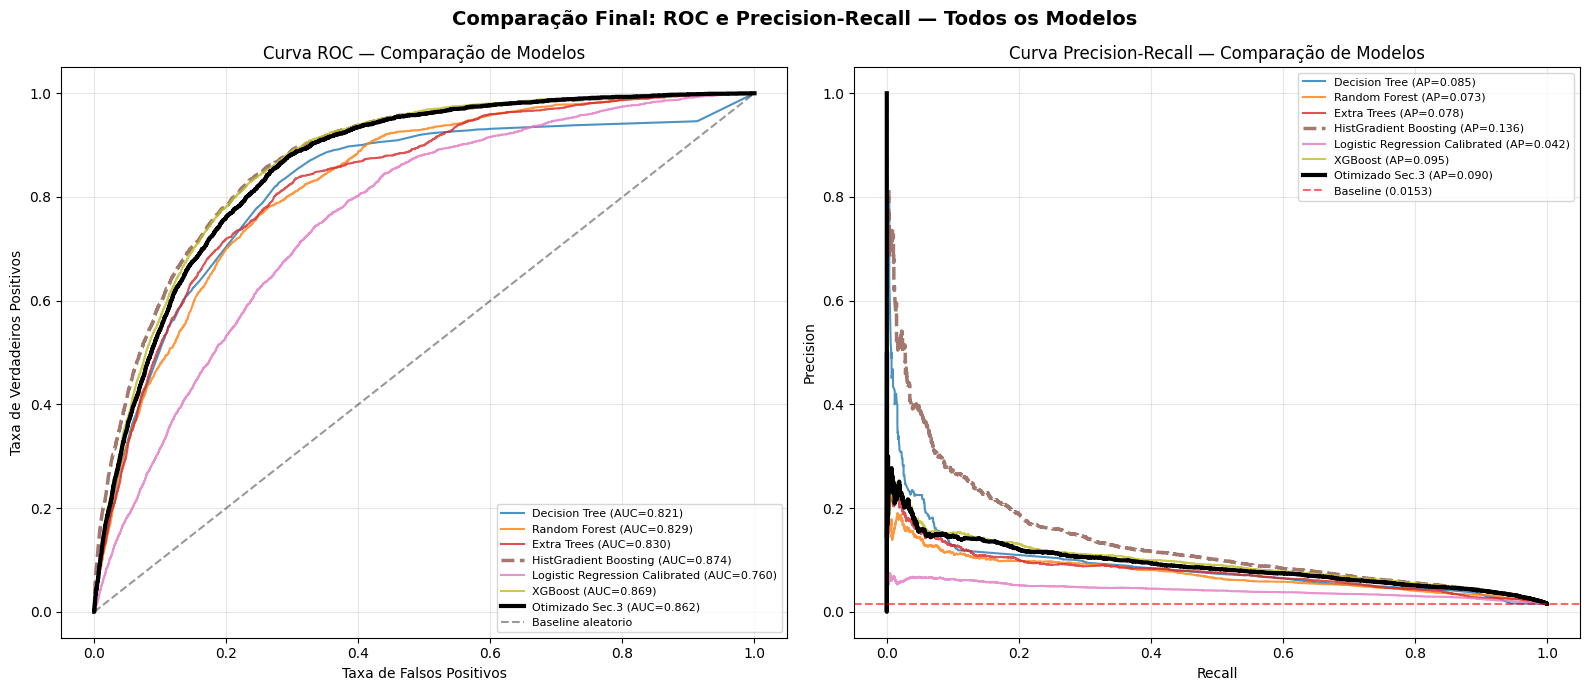

In [34]:
# Visualização final: ROC-AUC vs Average Precision — todos os modelos
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cores = plt.cm.tab10(np.linspace(0, 1, len(probabilidades_modelos) + 1))
i = 0

# Curva ROC — todos os candidatos + modelo otimizado
for nome, proba in probabilidades_modelos.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc = auc(fpr, tpr)
        estilo = '-' if nome != melhor_modelo_nome else '--'
        espessura = 1.5 if nome != melhor_modelo_nome else 2.5
        axes[0].plot(fpr, tpr, linestyle=estilo, linewidth=espessura,
                     color=cores[i], label=f'{nome} (AUC={roc:.3f})', alpha=0.8)
        i += 1

# Modelo otimizado (Secção 3)
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_final_s3)
axes[0].plot(fpr_opt, tpr_opt, linewidth=3, color='black',
             label=f'Otimizado Sec.3 (AUC={roc_auc_score(y_test, y_proba_final_s3):.3f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Baseline aleatorio')
axes[0].set_xlabel('Taxa de Falsos Positivos'); axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC — Comparação de Modelos', fontsize=12)
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(alpha=0.3)

# Curva PR — todos os candidatos + modelo otimizado
i = 0
for nome, proba in probabilidades_modelos.items():
    if proba is not None:
        prec, rec, _ = precision_recall_curve(y_test, proba)
        ap = average_precision_score(y_test, proba)
        estilo = '-' if nome != melhor_modelo_nome else '--'
        espessura = 1.5 if nome != melhor_modelo_nome else 2.5
        axes[1].plot(rec, prec, linestyle=estilo, linewidth=espessura,
                     color=cores[i], label=f'{nome} (AP={ap:.3f})', alpha=0.8)
        i += 1

prec_opt, rec_opt, _ = precision_recall_curve(y_test, y_proba_final_s3)
ap_opt = average_precision_score(y_test, y_proba_final_s3)
axes[1].plot(rec_opt, prec_opt, linewidth=3, color='black',
             label=f'Otimizado Sec.3 (AP={ap_opt:.3f})')
axes[1].axhline(y_test.mean(), color='red', linestyle='--', alpha=0.6,
                label=f'Baseline ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Comparação de Modelos', fontsize=12)
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Comparação Final: ROC e Precision-Recall — Todos os Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Avaliação dos Objetivos SMART

| Objetivo | Estado | Observação |
|---|---|---|
| **S** — Prever cancelamentos com dados históricos | Concluído | Modelo treinado sobre 1M+ registos reais |
| **M** — Avaliar com Accuracy, Precision, Recall, F1 | Concluído | Todas as métricas calculadas e comparadas |
| **A** — Dataset real com >1M registos | Concluído | 1.041.151 registos utilizados |
| **R** — Contribuir para eficiência operacional | Parcial | ROC-AUC ~0.87 útil para ranking de risco; F1 baixo limita alertas binários |
| **T** — Modelos desenvolvidos até ao fim da UC | Concluído | Pipeline completa: EDA → baseline → candidatos → otimização |

### 5.3 Limitações e Trabalho Futuro

**Limitações identificadas:**

1. **Desbalanceamento extremo (65:1):** a principal barreira ao desempenho. Mesmo com `class_weight='balanced'` e threshold otimizado, o F1 atingível tem um teto baixo.

2. **Target binário de cancelamentos (1.53%):** a variável alvo é rara. Prever atrasos ≥15 min seria mais equilibrado e alinhado com o objetivo declarado no projeto.

3. **Amostragem no GridSearch e TunedThresholdClassifierCV:** por razões computacionais, a otimização usou 30–50% dos dados. Com 100% dos dados a estimativa seria mais robusta.

**Trabalho futuro:**

- Reformular o target para `is_delayed` (atraso ≥15 min) e comparar resultados
- Realizar seleção de features para reduzir as 338 variáveis ao subconjunto mais informativo